# CLAM 全流程复现：从零教会 AI 读病理切片

> 写给零基础读者的实战笔记。不需要任何病理或深度学习背景，跟着走就能复现。

## 这个项目是干什么的？

想象你是一位病理科医生，面前有一张**全切片图像**（Whole Slide Image, WSI）——把活检组织放在显微镜下扫描成的超大图片。
它有多大？典型尺寸 **10 万 × 5 万像素**，相当于**几千张手机照片拼在一起**，一张图 1~2 GB。

医生给你的信息只有一句话：**"这个病人是肺腺癌"**。没有任何人告诉你肿瘤在图上的哪个位置——那是要花几个小时手工圈出来的，几千张片子根本圈不起。

**这个项目要做的就是**：只用"整张照片 = 什么病"这种最廉价的标签，教 AI 学会两件事——
1. **分对片子**（这张图是肺腺癌还是肺鳞癌？）
2. **顺便找出它看的是哪里**（把注意力分数叠回原图，就是一张"可疑区域热图"）

用的方法是 **CLAM**（哈佛 Mahmood Lab，发表于 *Nature Biomedical Engineering* 2021，[论文](https://www.nature.com/articles/s41551-020-00682-w) / [代码](https://github.com/mahmoodlab/CLAM)）。

### 一个比喻

> 把每张切片想成一本 5000 页的书，封面上只写了"这是一本悲剧"。
> CLAM 的做法：把书撕成一页一页（**切 patch**），用一个读过很多书的"速读器"把每页压缩成一页摘要（**特征提取**），
> 再训练一个"评论家"逐页打分、挑出最像悲剧的那几页，综合得出对整本书的判断（**注意力 MIL**）。
> 打完分，哪些页分数高，也就自然知道了。

---

## 名词表（先混个眼熟，后面会反复遇到）

| 名词 | 大白话解释 |
|---|---|
| **WSI** | 全切片图像，显微镜扫描出的超大病理图 |
| **patch** | 从 WSI 上切下来的小方块（256×256 像素），模型实际处理的最小单位 |
| **分割（segmentation）** | 自动找出图上"哪些是组织、哪些是空白背景" |
| **特征向量 / embedding** | 把一张 patch 图片压缩成 1024 个数字，相当于它的"指纹" |
| **ResNet50** | 在 ImageNet-1k（约 128 万张、1000 类自然图片）上有监督预训练的经典视觉网络，这里只当"特征提取器"用 |
| **MIL（多示例学习）** | 标签只给"一整包"（切片），不给包里的每个 patch；模型自己学会找关键 patch |
| **注意力（attention）** | 模型给每个 patch 打的重要性分数（加起来=1），高分=它认为最关键 |
| **k 折交叉验证** | 分 k 份轮流当考试卷的评估法。注意 CLAM 官方实现是"每折独立随机抽 80/10/10"的蒙特卡洛 CV，并非严格轮流（§6 有实测） |
| **AUC** | 分类模型常用指标，1.0 满分，0.5 等于瞎猜 |

## 流水线总览（本 notebook 的目录）

| 步骤 | 干什么 | 输入 → 输出 | 本机耗时 |
|---|---|---|---|
| §0-1 | 配置 + 环境验证 | 环境 → 能不能用 | 1 分钟 |
| §2 | 训练数据核验（✅ 已下载） | GDC 切片 + 标签 csv → 150 张就位确认 | 秒级 |
| §3 | 分割切块 + 特征提取（+质检对比图 +特征预览） | WSI → patch 坐标 → 1024 维特征 | 8 秒 + 36 秒/张 |
| §4 | 数据集补丁 + 双协议 5 折划分 | 标签 csv → MC + 严格两套 splits | 秒级 |
| §5 | 训练 CLAM（逐折接力） | 特征 + 标签 → 5 个 checkpoint | 每折几分钟 |
| §6 | 交叉验证评估（双协议对比 + 池化/患者级 AUC + 中心混杂） | 模型 → 严格 5 折每折均值 0.834，池化 0.783 | 1 分钟 |
| §7 | 注意力热图 ×11 | 模型 + 切片 → 可解释性图片 | ~10 秒/张 |
| §8 | 多组学：marker 体检 + 全基因组 DE + 形态预测表达（v1 输出有已知问题，v2 脚本待重跑） | 形态嵌入 + RNA-seq | 几分钟 |
| §9 | 生存分析 + Cox 预后建模（v1 生存表有偏、结果作废，v2 脚本待重跑） | clinical.json / TCGA-CDR → KM + Cox | 秒级 |
| §10 | 踩坑速查表 | 19 个真实坑 → 解法（14–19 来自 2026-10 审计） | 省你两天 |

**硬件**：Win11 / i7-10875H / 16GB / RTX 2060 6GB。整个流程在这个配置上都跑得动——这也是本笔记想证明的事。

> 搭建环境的 10 个坑（pip TLS 被掐、代理截杀 HF、Windows DLL 问题……）都有完整排查记录，见 `../docs/clam-setup-log.md`。
> 每一步的格式：🎯 目的 → 📥 输入 → ⚙️ 原理 → 📤 输出 → 💻 代码（逐行注释）→ ⚠️ 坑提示。

> 📌 **项目状态（2026-10-09 审计后更新）**
> 150 张 TCGA（LUAD/LUSC 各 75，144 名患者，138GB）→ 842 万 patch → ResNet50 特征（69GB）→ **双协议 5 折训练**：
> CLAM 默认蒙特卡洛 CV 每折 AUC 均值 **0.788 ± 0.181**（只覆盖 52/150 张）｜ 严格 5 折每折均值 **0.834 ± 0.090**，
> 把 5 折预测拼起来的池化 AUC **0.783**，患者级 **0.775（bootstrap 95% CI 0.70–0.85）**。
> ⚠️ 43 个组织来源中心每个只贡献一种亚型（中心与标签完全重合），150 张测试切片里 138 张的中心在训练集出现过，模型可能部分在"认医院"（§6）。
> ⚠️ §8 多组学和 §9 生存的 v1 结果有会改变结论的错误（表达矩阵可能混入癌旁正常样本；形态嵌入来自 5 个不一致的模型空间；
> 生存表漏取了 LUAD 的随访）。脚本已重写为 v2，需要在原机器上重跑；这两节的输出仍是 v1，已逐处标注，v1 文件归档在 `results/archive_v1/`。
> 逐切片预测明细在 `results/eval*/`，注意力热图在 `results/heatmaps/`，踩坑速查表见 §10。


## 0. 路径与运行器配置

🎯 **目的**：把所有文件路径集中在一处管理，以后整个项目搬家只改这一个 cell。

⚙️ **原理**：本 notebook 的计算都交给 `clam_latest` 这个 conda 环境里的 Python 去做（通过 `subprocess` 开子进程）。
好处是 notebook 本身用什么内核打开都行、不会污染环境，而且每条命令都能在终端里原样复现。
下面的 `run()` 函数是个"代跑员"：给它一条命令，它负责执行、实时打印输出、报用时；
给它一个 `skip_if` 路径，发现产物已存在就整步跳过（这就是"幂等"：重复执行不会重复干活）。

📤 **输出**：一组路径常量 + `run()` 函数。

In [1]:
import os, subprocess, time          # os=环境变量, subprocess=开子进程, time=计时
from pathlib import Path              # 处理文件路径的现代写法

# ============ 路径配置（项目搬家只需改这里） ============
ENV_PY   = r'D:/Software/Miniconda3/envs/clam_latest/python.exe'  # CLAM 专用 conda 环境的 python
CLAM_DIR = r'E:/Projects/DP/CLAM'            # CLAM 官方仓库（git clone 来的，含 Windows 补丁）
PROJ     = r'E:/Projects/DP/CLAM-tutorial'   # 本项目根目录（数据/脚本/结果都在这）

SLIDES_TCGA = f'{PROJ}/data/slides/tcga'     # TCGA 肺癌切片 ×150（已下载，138GB）
CSV_TCGA    = f'{PROJ}/data/dataset_csv/tcga_luad_lusc.csv'  # 标签表（下载脚本生成）
RES_TCGA    = f'{PROJ}/results/tcga'         # TCGA 预处理产物（patching/features）
RES_EVAL    = f'{PROJ}/results/eval'         # 5 折评估成绩单
RES_HM      = f'{PROJ}/results/heatmaps'     # 注意力热图
SCRIPT_DL   = f'{PROJ}/scripts/download_tcga.py'  # GDC 下载脚本（重下数据时才需要）
# =======================================================

def run(args, cwd=CLAM_DIR, env_extra=None, skip_if=None, timeout=7200):
    """代跑员：执行命令并实时打印。skip_if 指向的产物已存在则跳过。"""
    if skip_if is not None and Path(skip_if).exists():   # 幂等检查：产物在就不重跑
        print(f'[skip] 产物已存在: {skip_if}')
        return 0
    env = dict(os.environ)
    env.update({'PYTHONIOENCODING': 'utf-8', 'PYTHONUTF8': '1'})
    env.update(env_extra or {})
    t0 = time.time()
    print('$', ' '.join(str(a) for a in args), flush=True)
    p = subprocess.Popen([str(a) for a in args], cwd=cwd, env=env,
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, encoding='utf-8', errors='replace')
    for line in p.stdout:
        print(line, end='')
    p.wait(timeout=timeout)
    print(f'[exit {p.returncode}] 用时 {time.time()-t0:.1f}s')
    return p.returncode

print('ENV_PY 存在:', Path(ENV_PY).exists())   # True 才能继续
print('CLAM_DIR 存在:', Path(CLAM_DIR).exists())
print('切片目录:', len(list(Path(SLIDES_TCGA).glob("*.svs"))), '张 svs')

ENV_PY 存在: True
CLAM_DIR 存在: True


## 1. 环境验证

🎯 **目的**：正式开工前，确认四件事——GPU 能被 PyTorch 看到、OpenSlide 能打开 WSI 文件、关键包版本正确。

⚙️ **原理**：
- `torch.cuda.is_available()`：问 PyTorch"你看得到显卡吗"。看不到的话特征提取会慢 50 倍。
- `openslide.OpenSlide(...)`：读 WSI 的金标准库。它**不会把整张大图读进内存**（16GB 内存根本放不下），
  而是利用 WSI 的"金字塔分块"格式按需读取——这就是为什么 16GB 内存的笔记本也能处理 GB 级切片。

📤 **输出**：几行版本信息 + `ALL CHECKS PASSED`。

⚠️ **坑提示**（都来自真实搭建过程，详见 §10 速查表）：
- openslide 报 `Couldn't locate OpenSlide DLL` → Python≥3.8 的 ctypes 不再搜索 PATH，要额外装 `openslide-bin`
- `huggingface_hub` 必须钉在 **0.25.2**——新版删掉了 timm 0.9.8 还在用的 `cached_download` 函数

In [1]:
# 把验证代码写成字符串，交给 clam_latest 环境的 python 执行
check_code = r"""
import torch, openslide, timm, h5py, cv2, topk, huggingface_hub, glob
print('torch:', torch.__version__, '| cuda:', torch.cuda.is_available(),
      '| gpu:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')
print('timm:', timm.__version__, '| hf_hub:', huggingface_hub.__version__)
print('openslide lib:', openslide.lowlevel.get_version())
svs = sorted(glob.glob(r'E:/Projects/DP/CLAM-tutorial/data/slides/tcga/*.svs'))[0]
s = openslide.OpenSlide(svs)          # 随手打开一张 TCGA 切片试试
print('TCGA 首张:', s.dimensions, '| levels:', s.level_count,
      '| mpp:', round(float(s.properties.get('openslide.mpp-x', 0)), 3))
s.close()
print('ALL CHECKS PASSED')
"""
run([ENV_PY, '-c', check_code], cwd=PROJ)
# 输出里 'TCGA 首张' 显示成乱码：子进程按 GBK 输出中文、run() 按 UTF-8 解码，不影响检查结果

torch: 2.6.0+cu124 | cuda: True | gpu: NVIDIA GeForce RTX 2060
timm: 0.9.8 | hf_hub: 0.25.2
openslide lib: 4.0.1
TCGA ����: (80896, 100096) | levels: 4 | mpp: 0.233
ALL CHECKS PASSED


## 2. 训练数据：TCGA 肺癌切片（✅ 已下载完成）

🎯 **任务**：复现论文里的 **NSCLC 亚型分类**——肺腺癌（LUAD）vs 肺鳞癌（LUSC），两种最常见的肺癌，治疗方案不同，区分它们有真实临床意义。

📦 **数据现状**：**150 张诊断切片（138GB，LUAD/LUSC 各 75，144 名患者）已全部到位**（2026-10-01 先下 100 张，10-05 扩容 50 张——下载脚本有"已下载的永远保留"机制，扩容只增不换），连同同名患者的临床数据（144 例）和 RNA-seq 表达谱（167 个文件——比患者多，因为部分患者除原发肿瘤外还有癌旁正常或复发样本，分析时只能取原发肿瘤）。本节只做**完整性核验**，不需要再下载。

⚙️ **数据来源**（供复现参考）：
- [GDC](https://portal.gdc.cancer.gov/) 公开数据库，无需注册。TCGA 的项目名（LUAD/LUSC）本身就是切片级标签——**天然免费的标注**，正是弱监督想要的。
- 下载用 `scripts/download_tcga.py` 完成：查 GDC 列出开放诊断切片 → 滤掉退化小图（<0.3 GB）→ 每类随机抽 `--n` 张（本项目 75，固定种子可复现）→ 断点续传 → 生成 CLAM 格式标签 csv。
- **如需重下或扩充**：终端跑 `python scripts/download_tcga.py --n 100` 扩到每类 100 张（已下载的切片自动保留进数据集，断点续传不会重复下载）。

📤 **本节核验**：切片数/体积、manifest 记账、标签表分布。

In [ ]:
# 数据完整性核验（不是下载！数据已全部到位）
import json
manifest = json.load(open(f'{PROJ}/data/download_manifest.json'))   # 断点续传的"账本"
files = list(Path(SLIDES_TCGA).glob('*.svs'))
gb = sum(f.stat().st_size for f in files) / 1e9
print(f'磁盘上的 svs: {len(files)} 个, 共 {gb:.1f} GB')
print(f'manifest 记录完成: {len(manifest["completed"])}/{len(files)}')

import pandas as pd
df = pd.read_csv(CSV_TCGA)
print(f'标签表: {df.shape[0]} 行 | 标签分布: LUAD={sum(df["label"]=="LUAD")}, LUSC={sum(df["label"]=="LUSC")}')
print(f'独立患者: {df["case_id"].nunique()} | 切片: {len(df)}（一个患者可有多张切片）')
print('→ 下载已全部完成，本节只做核验，不需要再下载。')


磁盘上的 svs: 150 个, 共 137.9 GB
manifest 记录完成: 150/150
标签表: 150 行 | 标签分布: LUAD=75, LUSC=75
独立患者: 144 | 切片: 150（一个患者可有多张切片）
→ 下载已全部完成，本节只做核验，不需要再下载。


     case_id                                                     slide_id label
TCGA-78-7535 TCGA-78-7535-01Z-00-DX1.c4ca06f3-22d1-4e39-85c8-98d1fa2b0e60  LUAD
TCGA-50-5045 TCGA-50-5045-01Z-00-DX2.0FCA12EA-572E-4A7D-900D-6E200892170E  LUAD
TCGA-05-4402 TCGA-05-4402-01Z-00-DX1.c653ddc2-88c1-45ac-88e7-4e512b8e8d53  LUAD
TCGA-49-4490 TCGA-49-4490-01Z-00-DX4.4e94aeb6-f616-4bdd-82bc-2ca2f2b5a5c4  LUAD
TCGA-49-4512 TCGA-49-4512-01Z-00-DX2.341d7ff7-15e1-44f1-8818-b117fe98ca99  LUAD
TCGA-69-A59K TCGA-69-A59K-01Z-00-DX1.01EAF520-9AC1-4ECC-8EF3-B9122924A1E3  LUAD


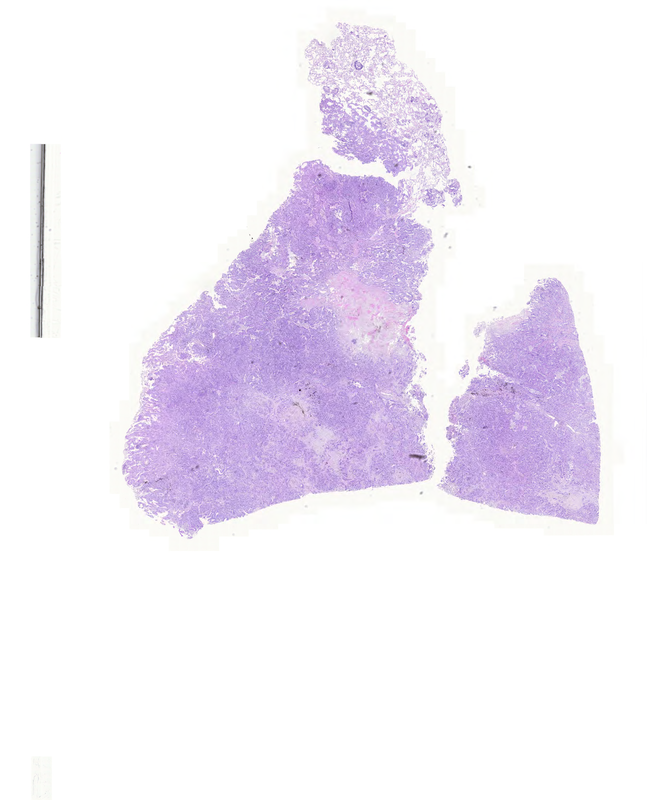

In [1]:
# 数据预览：标签表 + 亲眼看看一张真实 TCGA 切片
df = pd.read_csv(CSV_TCGA)
print(df.head(6).to_string(index=False))

# get_thumbnail 只取金字塔缩小层——几 MB 内存就能预览 GB 级大图
thumb_code = r"""
import openslide, glob
svs = sorted(glob.glob(r'E:/Projects/DP/CLAM-tutorial/data/slides/tcga/*.svs'))[0]
s = openslide.OpenSlide(svs)
s.get_thumbnail((1100, 800)).save(r'E:/Projects/DP/CLAM-tutorial/results/tcga/thumbnail_preview.png')
s.close()
"""
run([ENV_PY, '-c', thumb_code], cwd=PROJ)
from PIL import Image
Image.open(f'{RES_TCGA}/thumbnail_preview.png')   # 粉紫色=组织，白色=背景

## 3. 批量预处理：分割切块 + 特征提取（✅ 已完成）

🎯 **目的**：WSI 太大（10 万×5 万像素）没法直接喂模型，两步把它变成"数字指纹矩阵"：
1. **分割 + 切块**（`create_patches_fp.py`）：缩小 64 倍 → HSV 阈值找组织轮廓 → 在轮廓内按网格铺 256×256 格子，**只把格子坐标记进 .h5**（不存图片，这是新版快 10 倍的关键；图片用时按坐标回原切片现取）。
2. **特征提取**（`extract_features_fp.py`）：按坐标取图，用 **ResNet50**（ImageNet-1k 预训练，截断到 layer3 后做全局平均池化）把每个 patch 压成 **1024 维向量**。新版 CLAM 默认先把 256×256 的 patch 缩放到 224×224 再送进网络。后面的训练只吃这些数字，不碰图片——这是 CLAM 能在 6GB 显存上训练的根本原因。

⏱ **本机实测耗时**：切块 ~8 秒/张（CPU）；特征提取 ~176 patch/s（GPU，batch 64），首批 100 张约 **8 小时**（含 Windows 内存适配调试，详见 `docs/clam-setup-log.md`）。

⚠️ **倍率没有统一（2026-10 审计补充）**：`create_patches_fp.py` 默认在 level 0（扫描原始分辨率）切 256×256。TCGA 切片有 40×（约 0.25 µm/像素，比如 §1 打开的那张 mpp=0.233）也有 20×（约 0.5 µm/像素），
同样 256 像素，覆盖的组织面积能差 4 倍，模型看到的"一个 patch"不是同一尺度。CLAM 论文的做法是统一到 20× 等效：40× 切片切 512×512 再缩到 256（或用 `--patch_level` 选对应层）。
本项目没有统一。先跑 `python scripts/check_slide_mpp.py` 看 150 张的倍率分布；如果混了 20× 和 40×，统一后重新切块、提特征是最值得做的改进之一。

📥 **输入**：`data/slides/tcga/*.svs`
📤 **输出**：`results/tcga/patching/`（坐标+质检图）+ `results/tcga/features/`（.pt 训练用 / .h5 热图用）

> 💡 两步都有**幂等守卫**：产物已存在就跳过，中断后续跑不重复劳动。下面的 cell 重跑只会打印 `[skip]`。

In [ ]:
# 3a. 批量分割+切块（已完成；重跑会自动跳过）
run([ENV_PY, 'create_patches_fp.py',
     '--source', SLIDES_TCGA,
     '--save_dir', f'{RES_TCGA}/patching',
     '--patch_size', '256', '--seg', '--patch', '--stitch'],
    skip_if=f'{RES_TCGA}/patching/process_list_autogen.csv')

# 核验：150 张切片的坐标文件 + 总 patch 数
import h5py
h5s = sorted(Path(f'{RES_TCGA}/patching/patches').glob('*.h5'))
tot = 0
for f in h5s:
    with h5py.File(f, 'r') as h:
        tot += h['coords'].shape[0]
print(f'[已完成] 切块: {len(h5s)} 张切片的坐标文件 | 总 patch 数: {tot:,}')

[skip] 产物已存在: E:/Projects/DP/CLAM-tutorial/results/tcga/patching/process_list_autogen.csv
[已完成] 切块: 150/150 张切片的坐标文件 | 总 patch 数: 8,421,661


In [ ]:
# 3b. 批量特征提取（已完成；重跑会自动跳过已完成的切片）
run([ENV_PY, 'extract_features_fp.py',
     '--data_h5_dir', f'{RES_TCGA}/patching',
     '--data_slide_dir', SLIDES_TCGA,
     '--csv_path', f'{RES_TCGA}/patching/process_list_autogen.csv',
     '--feat_dir', f'{RES_TCGA}/features',
     '--batch_size', '64', '--slide_ext', '.svs'],
    env_extra={'HF_HUB_OFFLINE': '1'})

# 核验：150 个 .pt 特征文件 + 总体积
pts = sorted(Path(f'{RES_TCGA}/features/pt_files').glob('*.pt'))
gb = sum(f.stat().st_size for f in Path(f'{RES_TCGA}/features').rglob('*') if f.is_file()) / 1e9
print(f'[已完成] 特征: {len(pts)} 个 .pt | features 目录共 {gb:.1f} GB（每行 = 一个 patch 的 1024 维指纹）')

[已完成] 特征: 150/150 个 .pt | features 目录共 69.1 GB（每行 = 一个 patch 的 1024 维指纹）


### 3c. 肉眼质检：分割掩膜 vs 拼接重建（重要习惯！）

自动分割偶尔会翻车（把墨水渍当组织、把切片边缘破损圈进去……），所以每批切片都要抽查质检图：
- **左图（masks/）**：绿轮廓应紧贴组织边缘，不圈空白背景、不漏大块组织
- **右图（stitches/）**：把 .h5 里的 patch 坐标按原样拼回去——组织形状完整、无错位，说明坐标记录正确

（下图为 LUAD 切片 TCGA-55-8302 的质检图；150 张的质检图都在 `results/tcga/patching/masks|stitches/`，可逐一抽查）

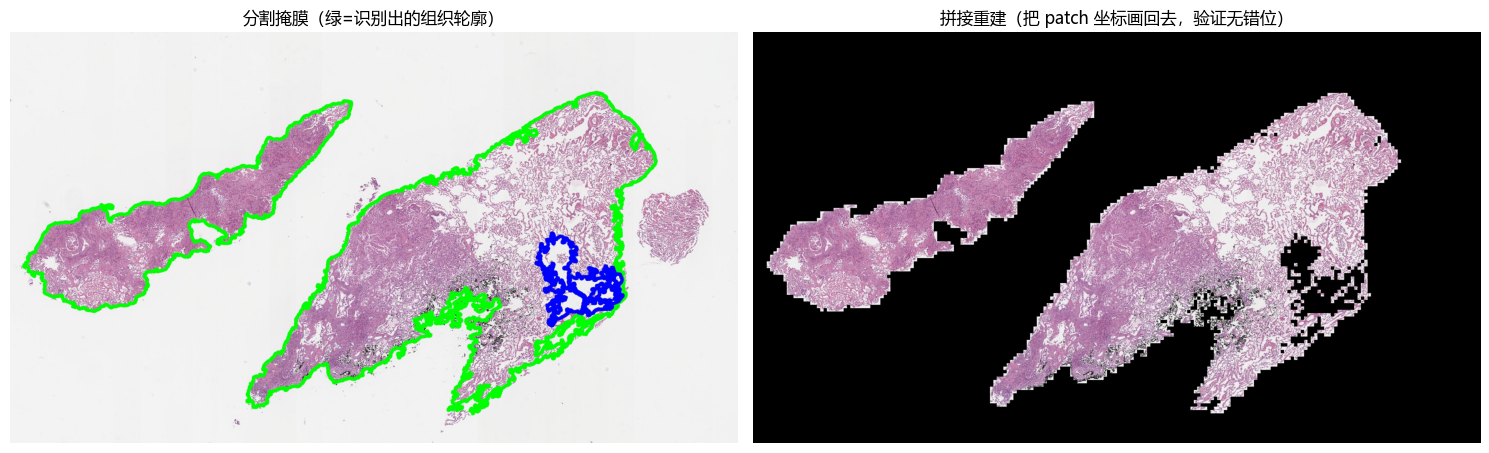

In [1]:
# 质检对比图：masks（绿轮廓）vs stitches（坐标重建）
from PIL import Image
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']; plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, p, t in zip(axes,
        ['patching/masks/TCGA-55-8302-01Z-00-DX1.E0C2B152-BBA9-4AA7-9E6B-BD57B68163CB.jpg',
         'patching/stitches/TCGA-55-8302-01Z-00-DX1.E0C2B152-BBA9-4AA7-9E6B-BD57B68163CB.jpg'],
        ['分割掩膜（绿=识别出的组织轮廓）', '拼接重建（patch 坐标画回去，验证无错位）']):
    ax.imshow(Image.open(f'{RES_TCGA}/{p}')); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

### 3d. 特征数据预览：1024 个数字到底长什么样？（小白版）

训练时模型吃的不是图片，而是每个 patch 的 **1024 维特征向量**。三个问题帮你看懂它：

**Q1：一个 patch 和它的特征向量怎么对应？** 左边是一块 256×256 的组织，右边是它的"指纹"——1024 个激活值。
没有一个维度代表"癌"这种人类概念（复习：特征不是温度计）；每个维度是 ResNet50 学到的某种纹理/形状探测器（"边缘强度""斑点密度"之类，无法逐一命名）。

**Q2：这些数字健康吗？** 看统计：没有 NaN、没有全零行、L2 范数分布集中——说明提取过程没出事故。

**Q3：特征里带着"癌种信息"吗？** 取一张 LUAD 和一张 LUSC 切片的 patch，把 1024 维压到 2 维（PCA）画出来：
两张切片的 patch 有一部分各自成团，中间有一大片重叠。这一步没用任何标签、没做任何训练。

⚠️ 但**每类只有一张切片**，这张图回答不了"癌种信息"的问题：两团分开，可能是因为癌种不同，也可能只是这两张片子的染色深浅、扫描仪、组织构成不同
（本数据集里每个中心只贡献一种亚型，"不同亚型"和"不同医院"常常是一回事）。要说特征里带亚型信息，得用很多张切片、最好在同一中心内比较；
§6 的交叉验证成绩才是更可靠的证据。下面图 2 的标题"天然分成两坨"说过头了，请以这段说明为准。

特征矩阵: (7386, 1024) float32 → 7386 个 patch × 1024 维
NaN: False | 全零行: 0
L2 范数: min 1.6 / 中位 2.0 / max 2.4


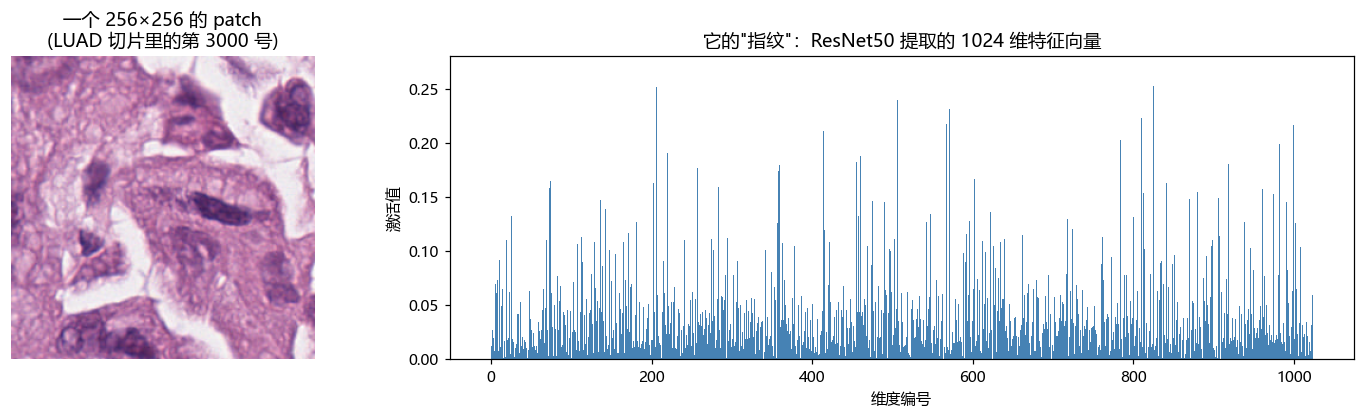

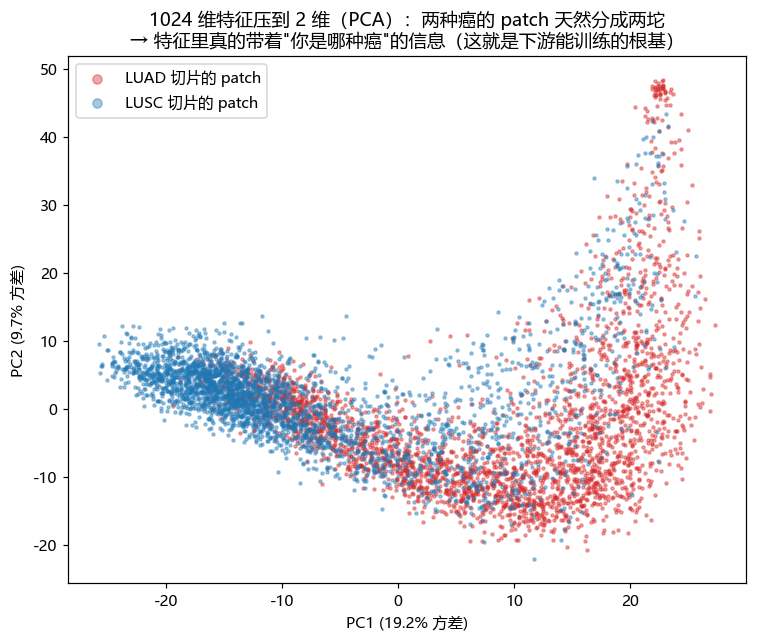

In [1]:
# 特征预览：① 一个 patch ↔ 它的特征向量  ② PCA 看两类癌的 patch 分不分得开
import torch, h5py, numpy as np, openslide, glob

luad = 'TCGA-55-8302-01Z-00-DX1.E0C2B152-BBA9-4AA7-9E6B-BD57B68163CB'
f_luad = torch.load(f'{RES_TCGA}/features/pt_files/{luad}.pt', map_location='cpu', mmap=True)

# ① 特征矩阵体检
norms = f_luad.norm(dim=1)
print(f'特征矩阵: {tuple(f_luad.shape)} float32 → {f_luad.shape[0]} 个 patch × 1024 维')
print(f'NaN: {torch.isnan(f_luad).any().item()} | 全零行: {(norms==0).sum().item()}')
print(f'L2 范数: min {norms.min():.1f} / 中位 {norms.median():.1f} / max {norms.max():.1f}')

# ② 一个 patch 的图片 vs 它的 1024 维向量（图 1）
# ③ PCA 散点（图 2）：红=LUAD patch，蓝=LUSC patch
# （这两张图是当时在交互环境里画的，绘图代码没有入库；图 2 的标题说过头了，见上方 ⚠️ 说明）
from PIL import Image
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, p in zip(axes, ['feat_preview_vector.png', 'feat_preview_pca.png']):
    ax.imshow(Image.open(f'{RES_TCGA}/{p}')); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. 告诉 CLAM 我们的数据在哪 + 划分训练/考试卷

🎯 **目的**：两件事——① CLAM 把具体数据集写在源码的 task 分支里（官方推荐这么改），我们自动把 `task_2` 分支指向自己的数据；② 生成 5 折交叉验证的划分。

⚙️ **原理**：
- **什么是 k 折交叉验证**：教科书定义是把 100 张切片分成 5 份、轮流当"考试卷"考 5 次取平均，比只考一次可信得多。**但注意**：CLAM 官方 `create_splits_seq` 并非严格分区，而是每折独立分层随机抽 80%/10%/10%（蒙特卡洛交叉验证）——实测 150 张里只有 52 张进过考试卷、**98 张（65%）从没被直接考过**。所以我们**两种协议都跑**：官方 MC 划分（为了和论文/教程可比）+ 自写严格 5 折（`scripts/make_strict_splits.py`，StratifiedGroupKFold 按患者分组，每张切片恰好进一次考试卷，150/150 全覆盖，患者零跨组）。成绩的对比解读见 §6。
- **为什么按"患者"分组**：同一个病人可能有好几张切片。如果一张进了训练集、另一张进了考试卷，等于提前泄题（模型可能"认出"这个病人）。CLAM 的 `patient_strat` 保证同一患者的片子永不跨组。
- **还可以更严：按"中心"分组**：同一家医院的切片染色、扫描风格相近。本数据集每个中心只出一种亚型，按患者分组时模型仍可能靠"认医院"拿分。
  `make_strict_splits.py --group-by site` 按 TCGA 条形码第二段（组织来源中心）分组，同一中心永不跨组（§6 有量化）。
- **划分文件要入库**：同样的 seed，不同 sklearn 版本的 `StratifiedGroupKFold` 给出的划分不同（审计时用 sklearn 1.9.1 重新生成，和本项目的划分对不上）。复现时直接用当时生成的 `splits_*.csv`。
- 补丁做的 4 处替换：标签 csv 路径、`label_dict`（LUAD=0, LUSC=1）、类别数 2、特征目录。

📥 **输入**：`data/dataset_csv/tcga_luad_lusc.csv`（case_id, slide_id, label）
📤 **输出**：MC 版 `CLAM/splits/task_2_tumor_subtyping_100/splits_0~4.csv` + 严格版 `CLAM/splits/task_2_strict150/splits_0~4.csv`

In [ ]:
from pathlib import Path

def patch_file(path, repls):
    """对文件做一组'查找→替换'，幂等：已是目标状态就跳过。"""
    src = Path(path).read_text(encoding='utf-8')   # 读整个文件
    orig = src                                     # 留个底，判断有没有改动
    for old, new in repls:                         # 逐条替换规则
        if old not in src and new not in src:      # 新旧都不在 = 模式对不上，提醒人工检查
            print(f'⚠️ 模式未命中: {path} :: {old[:60]}...')
        src = src.replace(old, new)
    if src != orig:                                # 有改动才写回
        Path(path).write_text(src, encoding='utf-8')
        print(f'patched: {path}')
    else:
        print(f'已是目标状态（幂等跳过）: {path}')

NEW_CSV = CSV_TCGA                          # 我们的标签表（绝对路径）
FEAT_PT = f'{RES_TCGA}/features'   # 特征根目录（注意：dataset_generic.py 内部会自己拼 'pt_files/'，这里千万别带上）

# ① create_splits_seq.py：换 csv + 标签字典 + 类别数
patch_file(f'{CLAM_DIR}/create_splits_seq.py', [
    ("args.n_classes=3", "args.n_classes=2"),                       # 3 类亚型 → 我们的 2 类
    ("csv_path = 'dataset_csv/tumor_subtyping_dummy_clean.csv'", f"csv_path = r'{NEW_CSV}'"),
    ("label_dict = {'subtype_1':0, 'subtype_2':1, 'subtype_3':2}", "label_dict = {'LUAD':0, 'LUSC':1}"),
])

# ② main.py：同上 + 特征文件目录
patch_file(f'{CLAM_DIR}/main.py', [
    ("args.n_classes=3", "args.n_classes=2"),
    ("csv_path = 'dataset_csv/tumor_subtyping_dummy_clean.csv'", f"csv_path = r'{NEW_CSV}'"),
    ("data_dir= os.path.join(args.data_root_dir, 'tumor_subtyping_resnet_features')", f"data_dir= r'{FEAT_PT}'"),
    ("label_dict = {'subtype_1':0, 'subtype_2':1, 'subtype_3':2}", "label_dict = {'LUAD':0, 'LUSC':1}"),
])

# 验证：在改过的文件里搜 LUAD，能搜到说明补丁生效
print(subprocess.run(['findstr', '/n', 'LUAD', f'{CLAM_DIR}/main.py', f'{CLAM_DIR}/create_splits_seq.py'],
                     capture_output=True, text=True).stdout)

In [ ]:
# 生成 5 折划分（--k 5）。想更严谨就用 --k 10（训练次数也翻倍）
run([ENV_PY, 'create_splits_seq.py', '--task', 'task_2_tumor_subtyping', '--seed', '1', '--k', '5'],
    skip_if=f'{CLAM_DIR}/splits/task_2_tumor_subtyping_100/splits_0.csv')

In [ ]:
# 4b. 生成"教科书式"严格 5 折（每患者恰好考一次，150/150 全覆盖）
# 原理：StratifiedGroupKFold 按患者分组分层抽样，val 从 train 里再切一刀（同样按患者分组）
# 产物校验内置在脚本里：断言无患者跨组 + 每张切片恰好进一次 test
run([ENV_PY, f'{PROJ}/scripts/make_strict_splits.py',
     CSV_TCGA, f'{CLAM_DIR}/splits/task_2_strict150'],
    skip_if=f'{CLAM_DIR}/splits/task_2_strict150/splits_4.csv')


严格 5 折已生成: task_2_strict150/splits_0~4.csv（150/150 张每张恰好进一次 test，断言通过）


In [ ]:
# 数据预览：5 折划分长什么样（生成后自动有内容）
sp = Path(f'{CLAM_DIR}/splits/task_2_tumor_subtyping_100/splits_0.csv')
if sp.exists():
    import pandas as pd
    df = pd.read_csv(sp)
    print('第 0 折形状:', df.shape, ' (三列长度不同，短的列末尾是空值，属正常)')
    print('train / val / test =',
          df['train'].notna().sum(), '/', df['val'].notna().sum(), '/', df['test'].notna().sum(), '张')
    print()
    print('→ MC 版每折约 80% 训练 / 10% 验证 / 10% 测试；严格版（task_2_strict150）则是 106 / 14 / 30，且 5 折 test 合起来恰好覆盖全部 150 张')
else:
    print('splits 尚未生成（等数据下完、跑完上一个 cell）')

第 0 折形状: (122, 3)  (三列长度不同，短的列末尾是空值，属正常)
train / val / test = 122 / 14 / 14 张

→ MC 版每折约 80% 训练 / 10% 验证 / 10% 测试；严格版（task_2_strict150）则是 106 / 14 / 30，且 5 折 test 合起来恰好覆盖全部 150 张


## 5. 训练 CLAM

🎯 **目的**：用"1024 维特征 + 切片级标签"，训练一个注意力 MIL 模型分辨 LUAD/LUSC。

### 5.1 三分钟直觉版

- **问题**：一张切片几千个 patch，标签只有一个（LUAD 还是 LUSC），没人告诉我们肿瘤在哪几个 patch 上。
- **CLAM 的做法**：给每个 patch 打一个"重要性分数"（注意力，全部加起来 = 1），按分数加权平均得到整张切片的表示，再做分类。
  分类错了 → 梯度回头惩罚错误的打分 → 注意力慢慢集中到真正有诊断价值的 patch 上。**"找证据"和"下诊断"是同一个优化过程。**
- **副产品**：训练完把每个 patch 的注意力分数按坐标画回切片，就是 §7 的热图。

> 📖 **想看懂原理？先跑这个**：姊妹 notebook [CLAM_原理_玩具版.ipynb](CLAM_原理_玩具版.ipynb) ——
> 用 200 张"假切片"（每个 patch 只有 4 个数，肿瘤位置我们有标准答案），亲手训练一个 30 行的注意力 MIL，
> 亲眼验证它没人教就找到了肿瘤 patch，最后附**玩具版 ↔ CLAM_SB 逐层对照表**。几分钟跑完，强烈推荐先看它再回来。
>
> 一句话概括对照关系：**CLAM = 玩具版 ×（更深的门控打分器 + 实例级聚类约束）**，骨架一模一样。

### 5.2 参数选择指南（对照 `main.py` 全部参数）

| 参数 | 默认 | 我们 | 什么时候改 |
|---|---|---|---|
| `--model_type` | clam_sb | clam_sb | `clam_mb` = 每类一个注意力分支（多类任务且各类形态差异大时更准，参数×类数）；`mil` = 无注意力的对照组 |
| `--model_size` | small | small | `[1024,512,256]` vs big `[1024,512,384]`；数据少就用 small |
| `--embed_dim` | 1024 | 1024 | **必须匹配特征提取器**：ResNet50=1024，CONCH=512，UNI=1024，UNI2-h=1536 |
| `--B` | 8 | 8 | 实例聚类每次采样的 patch 数；显存充裕、想要更强实例监督可加到 16/32 |
| `--bag_weight` | 0.7 | 0.7 | bag 损失占比，实例损失占 1-0.7=0.3；一般不动 |
| `--inst_loss` | svm | svm | `ce` 也行；配 `--no_inst_cluster` 可整个关掉实例支线（消融实验用） |
| `--lr` | 1e-4 | 2e-4 | README 示例值；小数据集宁小勿大 |
| `--drop_out` | 0.25 | 0.25 | 小数据可在 0.25~0.5 间调 |
| `--reg` | 1e-5 | 默认 | L2 权重衰减 |
| `--max_epochs` | 200 | 默认 | 配合 early_stopping：CLAM 的早停 patience=20、stop_epoch=50，最早第 50 个 epoch 才可能停 |
| `--early_stopping` | 关 | 开 | 验证集 loss 连续 20 个 epoch 无改善就停，并保存 val loss 最低的权重。注意本项目验证集每折只有 14~15 张，早停和选模型都很吵 |
| `--weighted_sample` | 关 | 开 | 两类数量不均时按频率倒数采样，防偏科（本项目两类各 75，开不开影响不大） |
| `--label_frac` | 1.0 | 默认 | 论文图 3 的"数据效率曲线"玩法：0.25/0.5/0.75 看性能随数据量的变化 |
| `--k` / `--k_start` / `--k_end` | 10 | 5 | 折数；调试时可 `--k_start 0 --k_end 1` 只跑第 0 折 |
| `--opt` | adam | 默认 | 也可 sgd，论文用 adam |

### 5.3 训练时盯着什么看

- `--log_data` 开了 tensorboard：在 `CLAM/results/luad_lusc_CLAM_sb_s1/` 里 `tensorboard --logdir=.` 看 `val_auc` 曲线（本项目因 Windows 上多折连写会段错误而关掉了）
- 小数据（<200 张）单折波动大是正常的，**看 5 折均值 ± 方差**，别看单折下结论
- 下一个 cell 先用随机数据把模型实例化跑一遍，亲眼看看各层张量的形状（共 79 万参数，还不到一张 patch 的像素值多），再开始真训练

### 5.4 双协议训练（2026-10-05 起）

同一批特征训两遍 5 折，唯一差别是划分目录：
- **MC 版**：`--exp_code luad_lusc_CLAM_sb`（默认划分目录）
- **严格版**：`--exp_code luad_lusc_CLAM_sb_strict --split_dir task_2_strict150`

Windows 稳定性经验：逐折独立进程（`--k_start i --k_end $((i+1))`），崩了只丢当前折；
checkpoint 只在折末保存，所以"有 checkpoint = 这折完成"就是断点续跑的全部依据。


In [1]:
# 亲手实例化 CLAM_SB：看看模型结构和每一层的张量形状（不需要训练数据，直接跑）
model_code = r'''
import sys; sys.path.insert(0, r'E:/Projects/DP/CLAM')
import torch
from models.model_clam import CLAM_SB

model = CLAM_SB(dropout=0.25, n_classes=2, subtyping=True, embed_dim=1024)
print(f'总参数量: {sum(p.numel() for p in model.parameters()):,}  (不到 1M，非常袖珍)')
print(model)

# 假装一张切片有 3000 个 patch，走一遍前向，看每个中间产物的形状
h = torch.randn(3000, 1024)
A = model(h, attention_only=True)
print()
print('注意力分数 A:', tuple(A.shape), ' → (类别分支数=1, patch 数=3000)')
logits, Y_prob, Y_hat, A_raw, _ = model(h)
print('logits:', tuple(logits.shape), ' → 2 个类的原始打分')
print('Y_prob:', Y_prob.detach().numpy().round(3), ' → softmax 后的类别概率')
print('softmax(A) 总和 =', torch.softmax(A_raw, dim=1).sum().item(), ' (恒等于 1，这就是"分配注意力"的含义)')
'''
run([ENV_PY, '-c', model_code])
# 读输出：① 这里没传 instance_loss_fn，所以打印的是默认 CrossEntropyLoss；正式训练用 --inst_loss svm（SmoothTop1SVM）。
# ② 中文乱码是 Windows 上 `python -c` 子进程按 GBK 输出、run() 按 UTF-8 解码造成的，不影响数值。

�ܲ�����: 790,791  (���� 1M���ǳ�����)
CLAM_SB(
  (attention_net): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Attn_Net_Gated(
      (attention_a): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): Tanh()
        (2): Dropout(p=0.25, inplace=False)
      )
      (attention_b): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): Sigmoid()
        (2): Dropout(p=0.25, inplace=False)
      )
      (attention_c): Linear(in_features=256, out_features=1, bias=True)
    )
  )
  (classifiers): Linear(in_features=512, out_features=2, bias=True)
  (instance_classifiers): ModuleList(
    (0-1): 2 x Linear(in_features=512, out_features=2, bias=True)
  )
  (instance_loss_fn): CrossEntropyLoss()
)

ע�������� A: (1, 3000)  �� (����֧��=1, patch ��=3000)
logits: (1, 2)  �� 2 �����ԭʼ���
Y_prob: [[0.472 0.528]]  �� softmax ���������


In [ ]:
# 注意：务必等第 3 步特征提取全部完成后再跑！
# Windows 稳定性经验：逐折跑（--k_start i --k_end i+1），每折一个独立进程，崩了只丢当前折；
# 且命令行加 -u（无缓冲）否则后台日志看不到进度
run([ENV_PY, 'main.py',
     '--drop_out', '0.25', '--early_stopping', '--lr', '2e-4',
     '--k', '5', '--exp_code', 'luad_lusc_CLAM_sb',     # exp_code = 实验名，结果目录用它命名
     '--weighted_sample', '--bag_loss', 'ce', '--inst_loss', 'svm',
     '--task', 'task_2_tumor_subtyping', '--model_type', 'clam_sb',
     '--subtyping', '--embed_dim', '1024',   # 注意:去掉了 --log_data(tensorboard 在 Windows 多折连写时会段错误)
     '--data_root_dir', f'{RES_TCGA}/features'],
    skip_if=f'{CLAM_DIR}/results/luad_lusc_CLAM_sb_s1',
    timeout=7200*2)

# 严格版：同一批特征，只换实验名和划分目录（实际是逐折独立进程跑的：加 --k_start i --k_end i+1）
run([ENV_PY, 'main.py',
     '--drop_out', '0.25', '--early_stopping', '--lr', '2e-4',
     '--k', '5', '--exp_code', 'luad_lusc_CLAM_sb_strict', '--split_dir', 'task_2_strict150',
     '--weighted_sample', '--bag_loss', 'ce', '--inst_loss', 'svm',
     '--task', 'task_2_tumor_subtyping', '--model_type', 'clam_sb',
     '--subtyping', '--embed_dim', '1024',
     '--data_root_dir', f'{RES_TCGA}/features'],
    skip_if=f'{CLAM_DIR}/results/luad_lusc_CLAM_sb_strict_s1',
    timeout=7200*2)

## 6. 评估：模型考了多少分？（双协议对比）

🎯 **目的**：汇总 5 折模型在各自测试集上的成绩——而且是**两种划分协议各评一次**。

⚙️ **原理**：`eval.py` 加载每折训练好的权重，在该折的测试集上算 AUC 和准确率。
**AUC** 越接近 1 越好，0.5 = 瞎猜。参考：CLAM 论文在 TCGA NSCLC 亚型（约一千张切片）上 AUC 约 0.95；我们只有 150 张，目标是跑通 + 看到一个可信的分数。

📤 **输出**：`results/eval/`（CLAM 默认 MC 划分）+ `results/eval_strict150/`（严格 5 折）。

### 📊 双协议 × 双规模成绩表（每折 AUC 的均值）

| 划分协议 | n=100 | n=150 |
|---|---|---|
| CLAM 默认（蒙特卡洛 CV） | 0.919 ± 0.065 | 0.788 ± 0.181 |
| 严格 5 折（每患者恰考一次） | 0.846 | **0.834 ± 0.090** |

150 张逐折（MC）：0.918 / 0.968 / **0.551** / **0.643** / 0.857
150 张逐折（严格）：0.855 / 0.788 / 0.936 / 0.705 / 0.889

### 📊 补充评估（2026-10 审计，`scripts/eval_cv_summary.py`，只读上面的 fold_*.csv）

| 严格 5 折，150 张 / 144 人 | 数值 |
|---|---|
| 每折 AUC 均值 ± SD | 0.834 ± 0.090 |
| **池化 AUC**（5 折预测拼起来，150 张） | **0.783** |
| **患者级 AUC**（多切片取平均，144 人） | **0.775**，bootstrap 95% CI 0.697–0.851 |
| 阈值 0.5 的准确率 | 0.713（LUSC 灵敏度 0.813，LUAD 特异度 0.613；60% 的切片被判为 LUSC） |
| 平均预测 p(LUSC) | 真 LUAD 0.418 / 真 LUSC 0.691；Brier 0.194 |
| 测试切片所在中心在训练侧出现过 | 138/150 |
| 见过的中心 / 没见过的中心 | AUC 0.789（n=138）/ 0.694（n=12） |

**怎么读这些成绩**：
- **同一个数据集、同一个模型、只是评估协议不同，结论就能从 0.92 晃到 0.79。** MC 划分 150 张里只有 52 张进过考试卷，fold 2/3 抽到难病人就崩（0.55/0.64）。
- **严格 5 折每折均值 0.834，但池化只有 0.783。** 5 个模型各自训练，输出概率的尺度不一样：每折内部排序不错，拼到一起用同一把尺子量就差一些。两个数都该报；只报每折均值会显得更好。
- **患者级 AUC 0.775，95% 区间 0.70–0.85。** 144 个患者的不确定性就这么大，n=100 和 n=150 之间的差别完全在噪声里。
- **AUC 不低、准确率却只有 0.71**：预测概率普遍挤在 0.5 附近，并且偏向 LUSC（阈值没校准）。要拿来做决策，需要在验证集上校准或另选阈值。
- **中心混杂**：43 个组织来源中心每个只贡献一种亚型。按患者分组时，138/150 张测试切片的中心在训练集里出现过，模型可以部分靠"认医院的染色/扫描风格"拿分（Howard et al. 2021, *Nat Commun* 12:4423 在 TCGA 上系统展示过这一点）。只有 12 张来自"没见过的中心"，AUC 0.69，样本太少不能下结论。要回答这个问题，需要 `make_strict_splits.py --group-by site` 按中心分组后重训。
- LUAD vs LUSC 在形态上差异较明显（腺癌成腺/鳞癌角化），是病理亚型里**相对容易**的任务，别把这个分数外推到难任务。
- 想涨分：统一倍率（§3 ⚠️）、加数据（`download_tcga.py --n 100`）、换病理基础模型特征（UNI2/CONCH）；想让分数更可信：按中心分组的 CV。

In [ ]:
# eval.py 里也有同样的 task_2 分支，先打同样的补丁
patch_file(f'{CLAM_DIR}/eval.py', [
    ("args.n_classes=3", "args.n_classes=2"),
    ("csv_path = 'dataset_csv/tumor_subtyping_dummy_clean.csv'", f"csv_path = r'{NEW_CSV}'"),
    ("data_dir= os.path.join(args.data_root_dir, 'tumor_subtyping_resnet_features')", f"data_dir= r'{FEAT_PT}'"),
    ("label_dict = {'subtype_1':0, 'subtype_2':1, 'subtype_3':2}", "label_dict = {'LUAD':0, 'LUSC':1}"),
])

# 6a. 评估 MC 版（CLAM 默认划分目录）
run([ENV_PY, 'eval.py',
     '--k', '5', '--models_exp_code', 'luad_lusc_CLAM_sb_s1',
     '--save_exp_code', 'luad_lusc_CLAM_sb_s1_cv',
     '--task', 'task_2_tumor_subtyping', '--model_type', 'clam_sb',
     '--results_dir', 'results', '--embed_dim', '1024',
     '--data_root_dir', f'{RES_TCGA}/features'],
    skip_if=f'{CLAM_DIR}/eval_results/EVAL_luad_lusc_CLAM_sb_s1_cv')

# 6b. 评估严格版（教科书 5 折）
# ⚠️ eval.py 三个机关（§10 坑 #12）：--save_exp_code 会被自动加 EVAL_ 前缀；
# --splits_dir 要给含 splits/ 的路径（不是划分目录名）；它没有 --subtyping 参数
run([ENV_PY, 'eval.py',
     '--k', '5', '--models_exp_code', 'luad_lusc_CLAM_sb_strict_s1',
     '--save_exp_code', 'luad_lusc_CLAM_sb_strict_s1_cv',
     '--splits_dir', f'{CLAM_DIR}/splits/task_2_strict150',
     '--task', 'task_2_tumor_subtyping', '--model_type', 'clam_sb',
     '--results_dir', 'results', '--embed_dim', '1024',
     '--data_root_dir', f'{RES_TCGA}/features'],
    skip_if=f'{CLAM_DIR}/eval_results/EVAL_luad_lusc_CLAM_sb_strict_s1_cv')


In [ ]:
# 数据预览：双协议 5 折评估结果（已跑完，在 results/eval 和 results/eval_strict150）
import pandas as pd
for tag, ev in [('MC（CLAM 默认划分）', Path(f'{PROJ}/results/eval')),
                ('严格 5 折', Path(f'{PROJ}/results/eval_strict150'))]:
    df = pd.read_csv(ev / 'summary.csv')
    print(f'== {tag} ==')
    print(df.to_string(index=False))
    print()
f4 = pd.read_csv(Path(f'{PROJ}/results/eval') / 'fold_4.csv')
f4['正确'] = (f4['Y'] == f4['Y_hat']).map({True: '✓', False: '✗'})
print('== MC fold_4.csv 前 6 行（逐切片预测明细：Y=真实, Y_hat=预测, p_0/p_1=两类概率）==')
print(f4.head(6).to_string(index=False))
print()
print('→ MC 版 5 个 fold_*.csv 只覆盖 52/150 张（65% 从未进过测试集）；')
print('   严格版 5 个 fold_*.csv 合起来恰好覆盖全部 150 张、每张一次。')


== MC（CLAM 默认划分） ==
 Unnamed: 0  folds  test_auc  test_acc
          0      0  0.918367  0.857143
          1      1  0.968254  0.875000
          2      2  0.551020  0.428571
          3      3  0.642857  0.533333
          4      4  0.857143  0.714286

== 严格 5 折 ==
 Unnamed: 0  folds  test_auc  test_acc
          0      0  0.855204  0.733333
          1      1  0.787500  0.741935
          2      2  0.935897  0.806452
          3      3  0.704762  0.620690
          4      4  0.888889  0.655172

== MC fold_4.csv 前 6 行（逐切片预测明细：Y=真实, Y_hat=预测, p_0/p_1=两类概率）==
                                                    slide_id   Y  Y_hat      p_0      p_1 正确
TCGA-69-8453-01Z-00-DX1.C472096B-95BA-42CD-ADEB-326C38F9DC95 0.0    1.0 0.498121 0.501879  ✗
TCGA-93-A4JO-01Z-00-DX1.314C53B6-603C-402B-8CF7-E3CE851A0A0F 0.0    1.0 0.375520 0.624479  ✗
TCGA-69-7760-01Z-00-DX1.7fc295e3-5bfc-4017-801c-491489d0eb34 0.0    0.0 0.570962 0.429038  ✓
TCGA-97-A4M0-01Z-00-DX1.BDDFB04C-2475-485A-9A85-C4B9EB15155E 0

In [ ]:
# 6b. 补充评估：池化 / 患者级 AUC、校准、组织来源中心混杂（只读 fold_*.csv，几秒）
# 结果已写入 results/eval_strict150/cv_summary.txt 和 results/eval/cv_summary.txt，上方表格就来自这里
run([ENV_PY, f'{PROJ}/scripts/eval_cv_summary.py', '--eval-dir', f'{PROJ}/results/eval_strict150'], cwd=PROJ)
run([ENV_PY, f'{PROJ}/scripts/eval_cv_summary.py', '--eval-dir', f'{PROJ}/results/eval'], cwd=PROJ)

## 7. 注意力热图：看看模型把注意力放在哪里

🎯 **目的**：把注意力分数叠回原切片，看模型的判断主要依赖哪些区域。

⚙️ **原理**：第 3 步存的 .h5 里有每个 patch 的坐标；热图脚本读出每个 patch 的注意力分数，按坐标叠回缩略图，再做轻微高斯平滑。
本项目没用官方 `create_heatmaps.py`（它会重新提一遍特征），用自写的 `scripts/make_heatmap.py` 复用已有特征，每张几秒。

📥 **输入**：训练好的权重（§5）+ 切片 + patch 坐标　📤 **输出**：`results/heatmaps/`

⚠️ **怎么读热图（重要）**：
- **注意力高 ≠ "这里是癌"**。注意力高只说明这个 patch 在切片表示里权重大。CLAM_SB 只有一个注意力分支，LUAD 和 LUSC 的证据都会拿高分；高分也可能落在出血、炭末、褶皱、笔迹等伪影上。
- **要配合预测概率看**。下面 4 张图来自 MC fold-4 模型（这 4 张切片都在该折测试集里）：TCGA-97-A4M0（LUAD，p=0.71）比较确定；
  TCGA-49-4514（LUAD，p=0.515）和 TCGA-43-A475（LUSC，p=0.60）接近瞎猜；**TCGA-98-A53H 是 LUSC，却被判成 LUAD（p=0.504）**。接近 0.5 的切片，热图几乎没有解释力。
- v1 热图标题里的概率被多做了一次 softmax（`make_heatmap.py` 已修正），显示值被压向 0.5。上面写的是 `results/eval/fold_4.csv` 里的真实概率。
- 想验证"模型找到了肿瘤"，需要病理医生圈出肿瘤区域，再算高注意力 patch 落在肿瘤区里的比例；只凭目测热图不够。

热图共 4 张:
  TCGA-43-A475-01Z-00-DX1_heatmap.png
  TCGA-49-4514-01Z-00-DX2_heatmap.png
  TCGA-97-A4M0-01Z-00-DX1_heatmap.png
  TCGA-98-A53H-01Z-00-DX1_heatmap.png


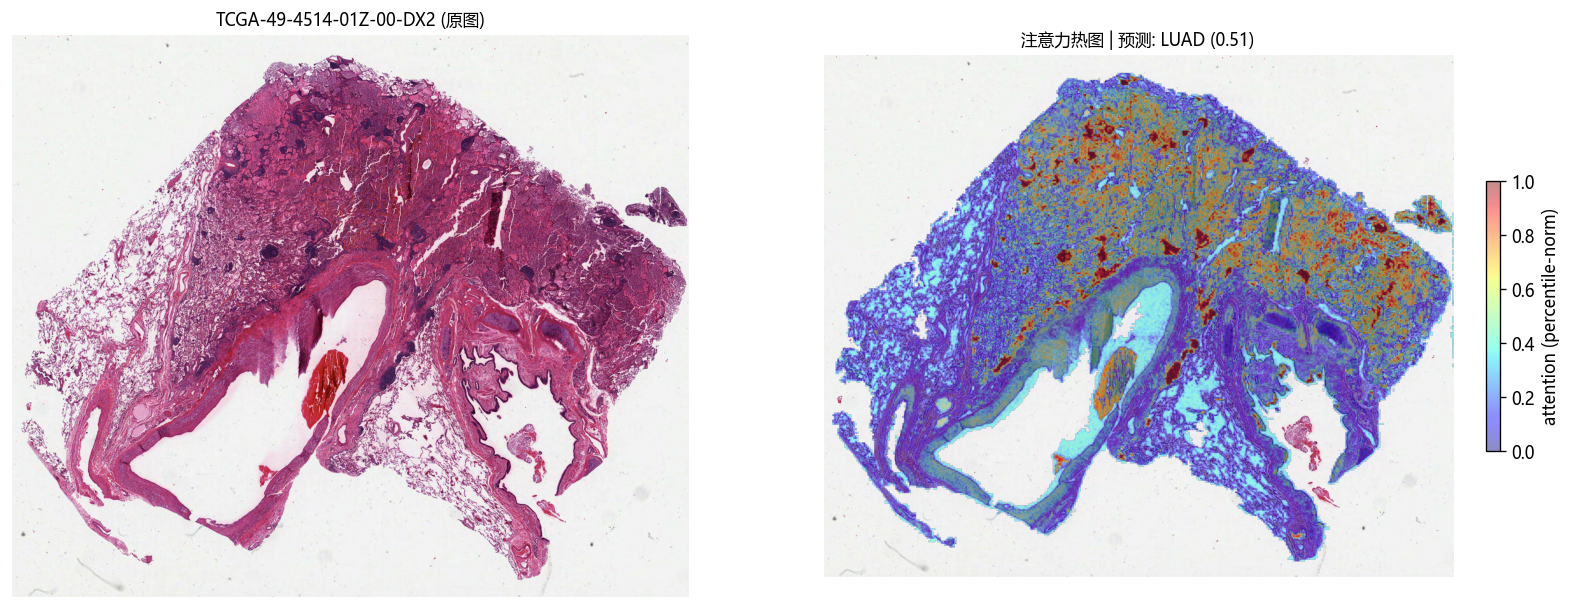

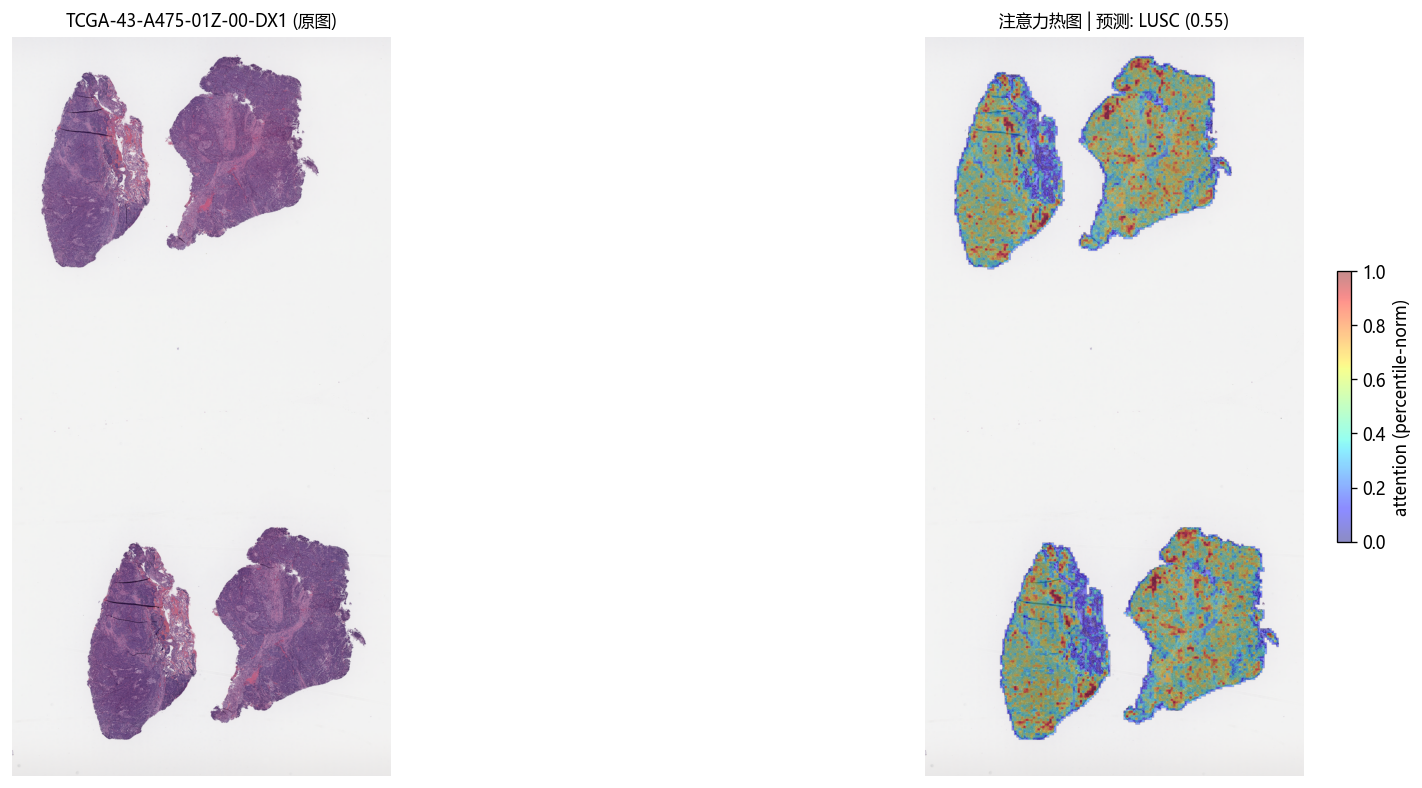

In [ ]:
# 注意力热图（轻量自研版：复用已有特征，不用官方 create_heatmaps 的重提取流程）
# 原理：model(h, attention_only=True) 直接给出每个 patch 的注意力分数（就是玩具版 §5 的 A），
#       按 patching 阶段保存的 coords 画回切片缩略图（jet 色标 + alpha 叠加），每张几秒钟。
# 脚本：scripts/make_heatmap.py
# 用法：python scripts/make_heatmap.py <slide_id前缀> <checkpoint> results/heatmaps
#
# 已为 MC150 fold-4 模型出图 4 张（该折测试集 2 LUAD + 2 LUSC；其中 TCGA-98-A53H 被判错），预览：
# ⚠️ 图标题里的概率来自修正前的脚本（多做了一次 softmax），以 results/eval/fold_4.csv 为准
from IPython.display import Image as IPImage, display
from pathlib import Path
hm = sorted(Path(f'{PROJ}/results/heatmaps').glob('*.png'))
print(f'热图共 {len(hm)} 张:', *[p.name for p in hm], sep='\n  ')
display(IPImage(f'{PROJ}/results/heatmaps/TCGA-49-4514-01Z-00-DX2_heatmap.png'))  # LUAD
display(IPImage(f'{PROJ}/results/heatmaps/TCGA-43-A475-01Z-00-DX1_heatmap.png'))  # LUSC


## 8. 多组学分析：切片形态 × 基因表达（加分项）

> ⚠️ **2026-10 审计**：本节下方的输出来自 v1 脚本（文件已归档到 `results/archive_v1/multiomics/`），有三个会改变结论的问题。v2 脚本已修正，但还没在原机器上重跑：
> 1. **表达矩阵可能混入癌旁正常样本**。167 个 RNA-seq 文件对应 144 个患者，v1 按患者覆盖写入：一个患者有原发肿瘤（样本类型 01）、癌旁正常（11）或复发（02）多个文件时，最后读到哪个就用哪个。clinical.json 显示 56 个患者在 GDC 有癌旁正常样本。v2 用 GDC 样本元数据只取原发肿瘤。
> 2. **形态嵌入来自 5 个不一致的空间**。v1 让每张切片用自己测试折的 CLAM 模型提嵌入，5 个模型参数不同，拼在一起做 PCA，主成分里混进了"来自哪一折"——用 v1 的 `morph_embeddings.csv` 实测（`scripts/audit_v1_embedding_folds.py`，结果在 `results/archive_v1/multiomics/fold_artifact_check.txt`），PC2–PC5 的方差有 81–97% 可由折号解释——v1 报告 NKX2-1、KRT5 相关最强的 PC3 就是其中之一。v2 默认改用 ResNet50 特征直接平均（meanpool：同一空间，也没经过用 LUAD/LUSC 标签训练的模型），另提供"每折模型只在自己的折内拟合和评估"的 clam 模式。
> 3. **把"亚型"当成了"形态 ≅ 分子"的证据**。CLAM 嵌入是为分 LUAD/LUSC 训练的，任何带亚型信息的特征都能预测亚型差异基因，"Top200 ∩ DE = 141"几乎是必然的。v2 同时报告只用亚型标签的基线，以及 ΔR²（形态在亚型之外多解释的部分）。
>
> 另外，v1 的"零泄漏勋章"叙述不成立：100 张时代剔除含泄漏切片的患者后，岭回归 R² 反而从 0.11 升到 0.17（`results/multiomics_strict100/`、`docs/clam-setup-log.md` §19）；150 张时 R² 变成 −0.09，主要是因为换了嵌入来源和样本，不能当作"泄漏被戳破"的证据。

🎯 **目的**：CLAM 从 H&E 切片里"看"到的形态信息，和肿瘤的分子特征（基因表达）有多少重合？重合部分是否只是"亚型"本身？

⚙️ **v2 流程**（一个脚本一步，都在 `scripts/`）：
0. `download_tcga.py --metadata-only`：只查 GDC 元数据（不下载切片和表达文件），生成 `rna_files.csv`（RNA 文件 ↔ 样本类型）和带 follow_ups 的 `clinical.json`
1. `embed_slides.py`：meanpool 嵌入（1024 维）+ 每折 CLAM 模型给全部 150 张切片提的嵌入（512 维）
2. `analysis_multiomics.py`：marker 体检；全部 marker × 形态 PC 的 Spearman 相关（统一做 BH 校正，并给出亚型内相关）；
   三个模型的嵌套交叉验证（只用亚型 / 只用形态 / 亚型 + 形态），随机 5 折和按中心分组 5 折各一遍
3. `analysis_de.py`：Wilcoxon 秩和 + BH，效应量用 log2(TPM+1) 均值差；ORA（背景 = 参与检验的基因）+ 可选预排序 GSEA；
   Reactome Keratinization（LUSC）和 Surfactant metabolism（LUAD）作阳性对照
4. `analysis_morph_predict.py`：全基因组三模型交叉验证，ΔR² 和"亚型内打乱形态"的零分布比较；CYT、增殖两个基因程序分数

⚠️ 中心与亚型完全重合（43 个中心每个只出一种亚型），DE 和形态—表达关联都无法把中心批次效应和亚型分开。

📤 **输出**：`results/embeddings/`、`results/multiomics/`

表达矩阵: 19938 个蛋白编码基因 × 144 个患者（114 个文件中匹配到标签的）

== marker 基因 sanity check（log1p TPM 中位数, Mann-Whitney）==
  NKX2-1  (LUAD（TTF-1，肺腺癌标志）): LUAD中位 4.87 vs LUSC中位 1.99, p=7.38e-16
  TP63    (LUSC（鳞癌标志）): LUAD中位 1.13 vs LUSC中位 5.20, p=6.05e-18
  KRT5    (LUSC（鳞癌角化）): LUAD中位 1.23 vs LUSC中位 7.83, p=3.22e-20
  KRT6A   (LUSC（鳞癌角化）): LUAD中位 1.39 vs LUSC中位 7.99, p=1.31e-19

== 计算形态嵌入（严格 k 折：每张切片用它当 test 那一折的模型，零泄漏）==
  选折来源统计: test折 150 张（零泄漏）/ val折 0 张（近似无泄漏） / 借用fold-0 0 张（泄漏，见下）
形态嵌入: 144 患者 × 512 维（干净患者 144，含泄漏切片的患者 0）
嵌入已保存: morph_embeddings.csv (+_meta.csv)

== 形态主成分 × marker 表达（Spearman 相关）==
  NKX2-1 : 最强相关 PC3, r=+0.32, p=7.61e-05
  TP63   : 最强相关 PC1, r=+0.35, p=2.09e-05
  KRT5   : 最强相关 PC3, r=-0.35, p=2.18e-05
  KRT6A  : 最强相关 PC1, r=+0.35, p=1.39e-05

岭回归（形态 PC1-5 → NKX2-1 表达）5折CV R²: -0.09 ± 0.27
（>0 说明形态里确实含有该基因表达的信息；数值温和属正常——形态只是表达的一个模糊投影）

== 稳健性复核：剔除含泄漏切片的 0 个患者，仅用干净 n=144 ==
  图右那对（PC1 × KRT6A）：干净子集 r=+0.35, p=1.4e-05（全体 r=+0.35 → 方向/量级一致即说明结论不是泄漏造成的）
  岭回归干净子集 5折CV R²: -0.09 ± 0.27

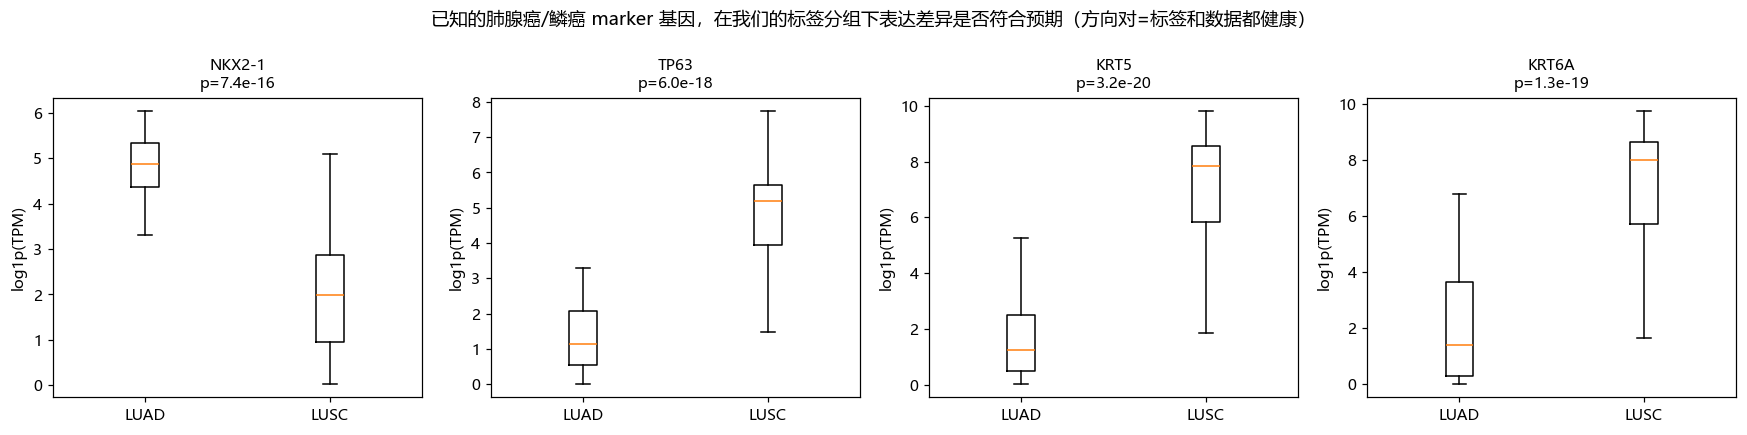

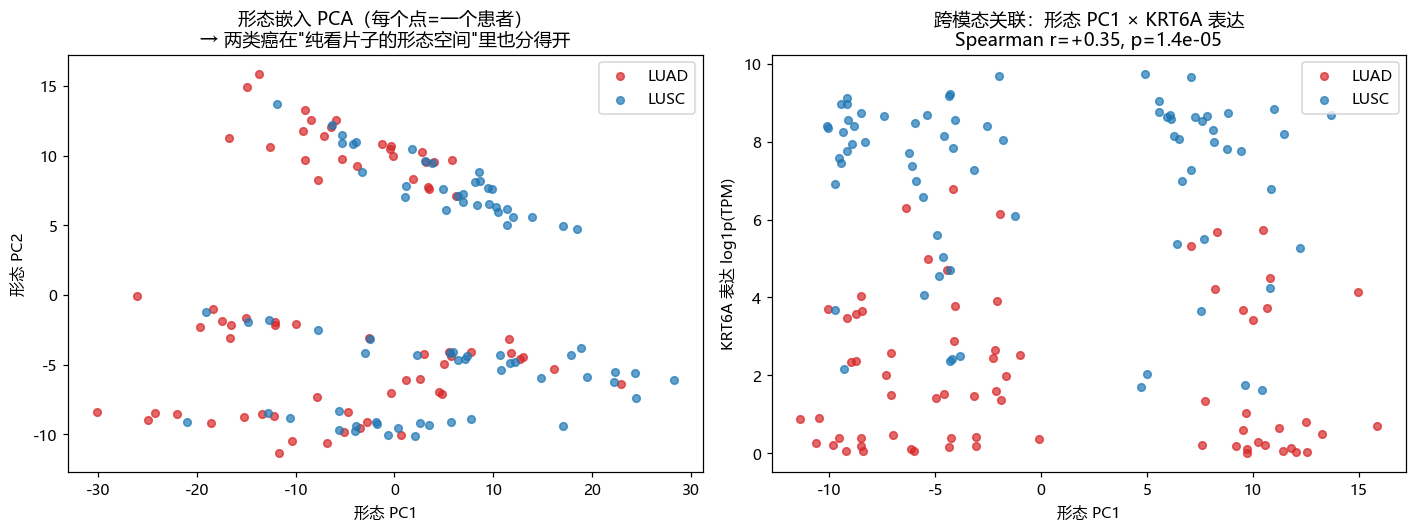

In [ ]:
# 8a. ⚠️ v1 输出回放（审计前的脚本，已知问题见上方说明；v1 文件归档在 results/archive_v1/multiomics/）
import pathlib
from IPython.display import Image, display
out_dir = pathlib.Path(f'{PROJ}/results/archive_v1/multiomics')
print((out_dir / 'run_log.txt').read_text(encoding='utf-8'))
display(Image(filename=str(out_dir / 'markers_boxplot.png')))
display(Image(filename=str(out_dir / 'morph_vs_expr.png')))


### 📊 v1 多组学结果，以及哪些解读需要收回

- **Marker 体检**（v1）：NKX2-1 在 LUAD 高（中位 4.87 vs 1.99），TP63/KRT5/KRT6A 在 LUSC 高（p 最低 3e-20）。方向正确，说明标签和表达数据整体对得上；但个别患者用的可能是癌旁正常样本，v2 重跑后数值会变。
- **形态 PC × marker**（v1，|r|=0.32–0.35）：每个 marker 都是在 PC1–5 里挑 |r| 最大的一个报告，挑选之后 p 值偏小；PC 还混着折号信号。
  上面右侧散点图也画错了一列：代码用 1 起的 PC 编号去索引 0 起的数组，标题写 PC{k}、画的却是 PC{k+1}。**收回。**
- **岭回归 R²=−0.09**（v1，PC1–5，未打乱的 5 折）和 §8c 的 NKX2-1 留一 R²=0.165（PC1–10）互相矛盾：两者特征数和交叉验证方式都不同，v1 文字却分别给出"无法预测"和"可预测"。**收回**，以 v2 的三模型对比为准。
- **全基因组 DE 1,526 个显著基因**（v1）：检验方法本身（Wilcoxon + BH）合理，问题在样本选择和效应量（见 8b）。
- **"形态可预测基因 ≅ 差异表达基因（OR=23.5）"**不是独立证据（见本节开头第 3 点）。**收回。**

> **一句话**：v1 站得住的只有"marker 方向对"和"两型之间差异基因很多"。形态与分子的关系，要等 v2 在同一个嵌入空间、带着亚型基线重算之后再下结论。

### 8b. 全基因组差异表达 + 通路富集（v1 输出）

v1：19,938 个蛋白编码基因，去掉两组均值都 <1 TPM 的之后 15,206 个进入 Mann-Whitney + BH，**1,526 个显著**（FDR<0.05 且 |log2FC|>1；LUAD 高 638 / LUSC 高 888）。

v1 的问题（v2 已改）：
- **log2FC 用算术均值算**：log2((meanA+1)/(meanB+1)) 会被少数极端样本拉大。下面输出里 SST 的 log2FC=5.8，q=0.29，根本不显著；TFF1 log2FC=5.8，q=0.05。v2 改用两组 log2(TPM+1) 的均值之差。
- **富集的背景不对**：每侧只送 top 200 个基因给 Enrichr，背景是 Enrichr 默认的全基因组，而不是真正参与检验的 15,206 个基因。v2 用全部显著基因做超几何 ORA（背景 = 参与检验的基因），另加预排序 GSEA。
- **解读说过头了**：v1 说 LUSC 侧的 p53 Pathway / KRAS Signaling Dn / Apical Junction 是"鳞癌的经典分子特征，方向全部符合生物学常识"。实际两侧都富集 Estrogen Response，每个通路只命中个位数基因（如 LUSC 侧的 KRT13、SFN、PERP、TP63）。v2 加了更直接的阳性对照：Reactome Keratinization（LUSC）和 Surfactant metabolism（LUAD）。
- 中心与亚型完全重合，DE 结果里可能含中心批次成分。

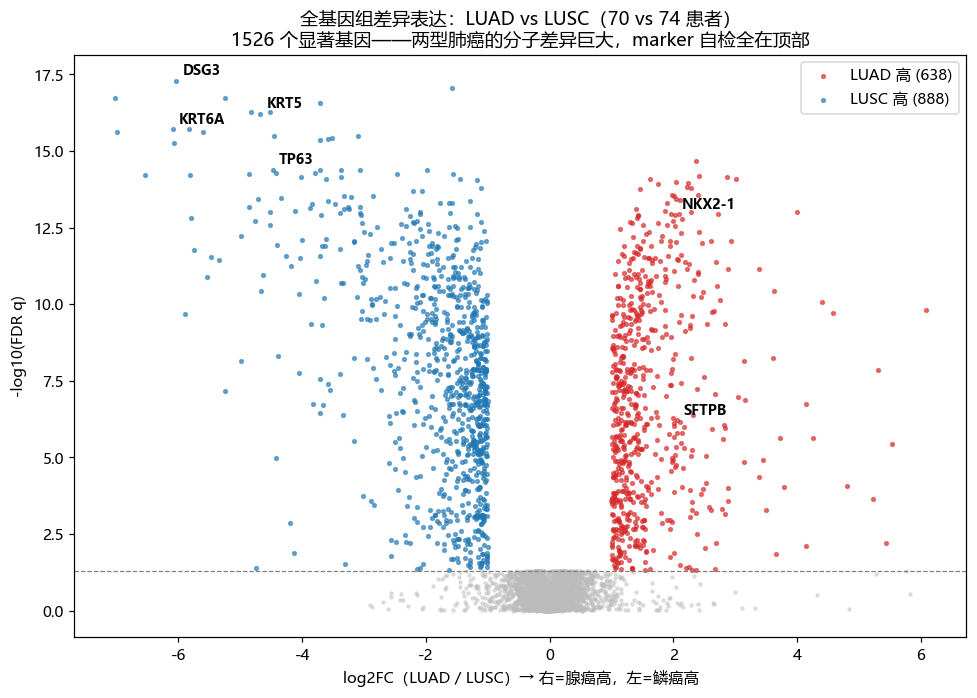

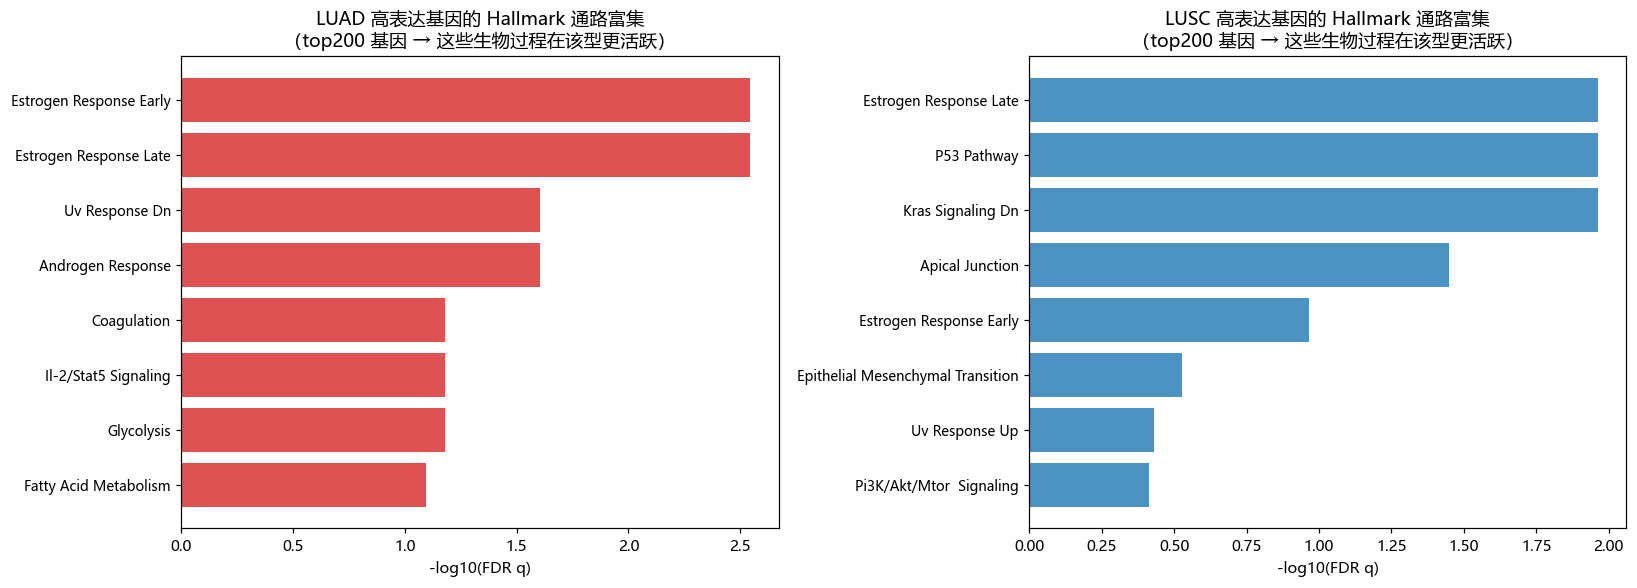

显著基因 1526 个 | log2FC 最高的 5 个（LUAD 方向）:
        mean_LUAD  mean_LUSC  log2FC_LUAD_vs_LUSC          q_BH
gene                                                           
TM4SF4      93.29       0.39                6.084  1.521991e-10
SST        144.54       1.57                5.822  2.905415e-01
TFF1       283.05       4.23                5.763  5.289534e-02
FGB         62.88       0.38                5.530  3.675787e-06
MUC6        61.21       0.44                5.435  6.201550e-03


In [ ]:
# ⚠️ v1 输出回放：DE 火山图 + Enrichr 富集条形图（审计前的 analysis_de.py）
import pandas as pd
display(Image(filename=str(out_dir / 'de_volcano.png')))
display(Image(filename=str(out_dir / 'enrich_barplot.png')))
de = pd.read_csv(out_dir / 'de_table.csv', index_col=0)
sig = de[(de['q_BH'] < 0.05) & (de['log2FC_LUAD_vs_LUSC'].abs() > 1)]
print(f'显著基因 {len(sig)} 个 | log2FC 最高的 5 个（LUAD 方向）:')
print(de.nlargest(5, 'log2FC_LUAD_vs_LUSC')[['mean_LUAD', 'mean_LUSC', 'log2FC_LUAD_vs_LUSC', 'q_BH']].to_string())


### 8c. 形态 → 表达：全基因组预测（v1 输出）

v1：14,843 个基因（平均 TPM≥1），形态嵌入 PC1–10 → 岭回归 → 帽子矩阵闭式留一法。R² 前五名 CACFD1 0.240 / GLOD5 0.238 / SERPINB5 0.232 / DSC3 0.204 / BLM 0.203；
全基因组平均 R² 为负（−0.05），即多数基因预测得还不如直接猜均值；Top200 与 DE 重叠 141 个（Fisher OR=23.5）。

需要更正的地方：
- α 在 0.1–100 上按全基因组平均 LOO R² 挑，选中了边界值 100（网格不够大）；挑 α 和报告 R² 用的是同一批 LOO 结果，略乐观。v2 每个基因在训练折内部用 LOO 选 α，外层 5 折报告。
- 嵌入带亚型信息，"形态可预测"的基因大都是亚型差异基因，重叠高在意料之中，不能说明"形态与分子同构"。v2 报告 ΔR²（亚型+形态 − 只用亚型），并和"亚型内打乱形态"的零分布比较；Top200 重叠按 R²(形态) 和 ΔR² 两种排序分别报。
- 嵌入来自 5 个不一致的模型空间（见 §8 开头）。

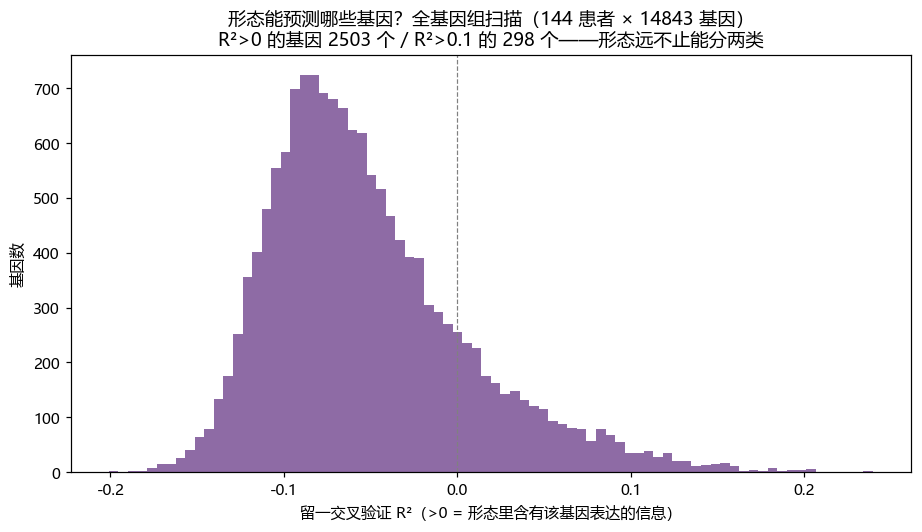

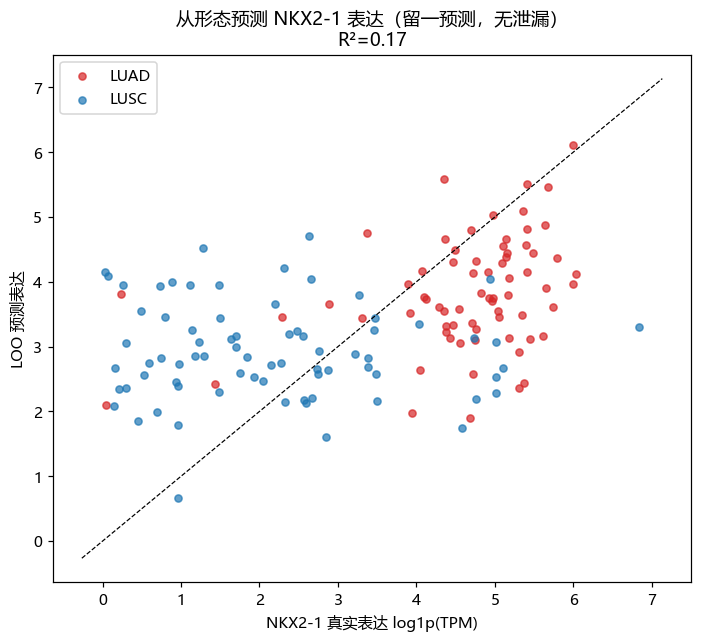

R² 前 5 名:
    gene  R2_loo
  CACFD1  0.2396
   GLOD5  0.2383
SERPINB5  0.2321
    DSC3  0.2038
     BLM  0.2032


In [ ]:
# ⚠️ v1 输出回放：R² 分布直方图 + NKX2-1 留一散点（审计前的 analysis_morph_predict.py）
display(Image(filename=str(out_dir / 'morph_predict_hist.png')))
display(Image(filename=str(out_dir / 'morph_predict_nkx2.png')))
r2 = pd.read_csv(out_dir / 'morph_predict_r2.csv')
print('R² 前 5 名:')
print(r2.head(5).to_string(index=False))


In [ ]:
# 8d. v2 重跑（2026-10 审计后的脚本；还没在原机器上跑过，所以这一格没有输出）
# 顺序：补元数据（只查 GDC 元数据，不下载切片/表达文件）→ 提嵌入 → 多组学 → 生存 → Cox
run([ENV_PY, f'{PROJ}/scripts/download_tcga.py', '--metadata-only'], cwd=PROJ)
run([ENV_PY, '-X', 'utf8', '-u', f'{PROJ}/scripts/embed_slides.py'], cwd=PROJ)
for s in ['analysis_multiomics.py', 'analysis_de.py', 'analysis_morph_predict.py',
          'analysis_survival.py', 'analysis_cox.py']:
    run([ENV_PY, '-X', 'utf8', '-u', f'{PROJ}/scripts/{s}'], cwd=PROJ)
# 想看 CLAM 嵌入版本：analysis_multiomics.py / analysis_morph_predict.py / analysis_cox.py 都支持 --embedding clam
print((pathlib.Path(f'{PROJ}/results/multiomics') / 'run_log.txt').read_text(encoding='utf-8'))
print((pathlib.Path(f'{PROJ}/results/survival') / 'run_log.txt').read_text(encoding='utf-8'))

## 9. 临床生存分析（加分项）

> ⚠️ **2026-10 审计：v1 的"缺失数据陷阱"结论需要更正。** 缺失不是 GDC 数据"非随机缺失"，而是我们自己的提取代码造成的：
> - `download_tcga.py` 请求临床数据时只 expand 了 demographic / diagnoses / exposures，**没有 follow_ups**。TCGA-LUAD 的随访天数记在 follow_ups 里，所以 70 个 LUAD 患者中 44 个活着的全部"没有随访时间"；
> - 被剔除后，留下的 26 个 LUAD **全是死亡病例**（事件率 100%），而 LUSC 留下 73 例、死亡 35 例。任何涉及 LUAD 的生存比较都被这个选择偏倚主导；
> - v1 用 `a or b` 取随访天数，0 天会被当成缺失（这里没造成额外丢失，但属于隐患）。
>
> 因此 v1 的 LUAD vs LUSC 曲线（"LUAD 中位 1.2 年 vs LUSC 3.0 年"）、分期 KM、§9b 的全部 Cox 结果（包括"LUSC HR=0.39"和各个 C-index）都建立在有偏的表上，**作废**（v1 文件归档在 `results/archive_v1/survival/`）。
> 正确做法是把随访取全（`download_tcga.py --metadata-only` 会带上 follow_ups），或者直接用 **TCGA-CDR**（Liu et al. 2018 *Cell*，TCGA 官方整理的 OS/PFI/DSS 终点表）。
> v1 还有两个小问题：性别读的是 `demographic.gender`（GDC 已改名为 `sex_at_birth`，读出来全是空）；分期取"第一个有分期的诊断记录"而不是原发诊断（52 个患者有 2 条以上诊断记录；本数据集只影响 1 人：TCGA-55-A492 被记成 IIA，原发诊断是 IA）。
>
> 教训本身仍然成立，而且更深一层：**生存分析第一步是按 组别 × 结局 检查缺失；发现缺失不平衡，先怀疑自己的提取代码，再怀疑数据。**

🎯 **目的**：演示 WSI 项目的标准下游分析——把临床结局（生存）接进来。

⚙️ **原理**：Kaplan-Meier 曲线估计"确诊后 t 年仍存活的概率"，log-rank 检验比较曲线。`vital_status=Dead` → 用 `days_to_death`（事件）；`Alive` → 用最后一次随访的天数（删失：在那之后的情况未知）。

**v2**（`analysis_survival.py`）：TCGA-CDR 优先，否则用 GDC（含 follow_ups）；缺失检查写成程序（任一组缺失 >20% 或组间相差 >15 个百分点就停下并提示怎么补）；
分期取原发诊断、合并为 I / II / III-IV（IV 期只有 2 例）；三组 log-rank + 趋势检验，并报告以亚型分层的版本。

📤 **输出**：`results/survival/`。脚本：`analysis_survival.py`（KM，本节）+ `analysis_cox.py`（Cox，§9b）

== 第一步：检查缺失模式（这是本分析最重要的一张表）==
97 个患者中 99 个有完整生存记录，45 个因无随访时间被剔除
被剔除病例的构成：
label  vital
LUAD   Alive    44
LUSC   Dead      1
→ 26 例被剔除者全是 Alive 的 LUAD！缺失不是随机的：它们都活着，剔除后 LUAD 曲线必然假性偏糟。

== 分期 KM（主分析）==
各期例数: {'I': 51, 'II': 28, 'III': 15, 'IV': 2}
Stage I vs III: log-rank p=0.26（曲线方向正确；样本量小未达显著，符合预期）

== LUAD vs LUSC（教学演示，结论无效）==
表面上: LUAD 中位 1.2 年 vs LUSC 3.0 年, p=0.000
但这个"显著差异"完全是缺失数据造成的假象——被剔除的 26 例全是活着的 LUAD。
教训：KM 之前先按 标签×结局 交叉检查缺失构成，缺失不随机时任何曲线都可能撒谎。

✅ 图已保存: E:/Projects/DP/CLAM-tutorial/results/survival/km_by_stage.png, E:/Projects/DP/CLAM-tutorial/results/survival/km_luad_vs_lusc.png


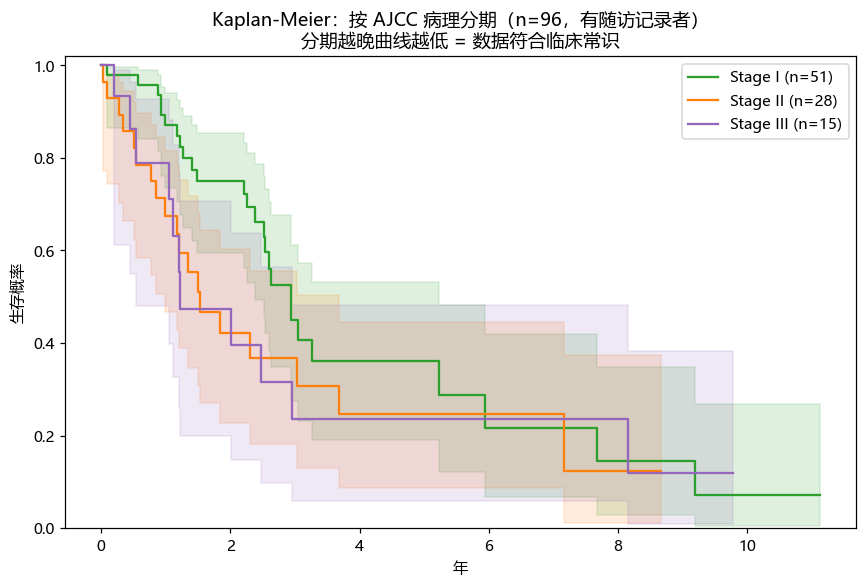

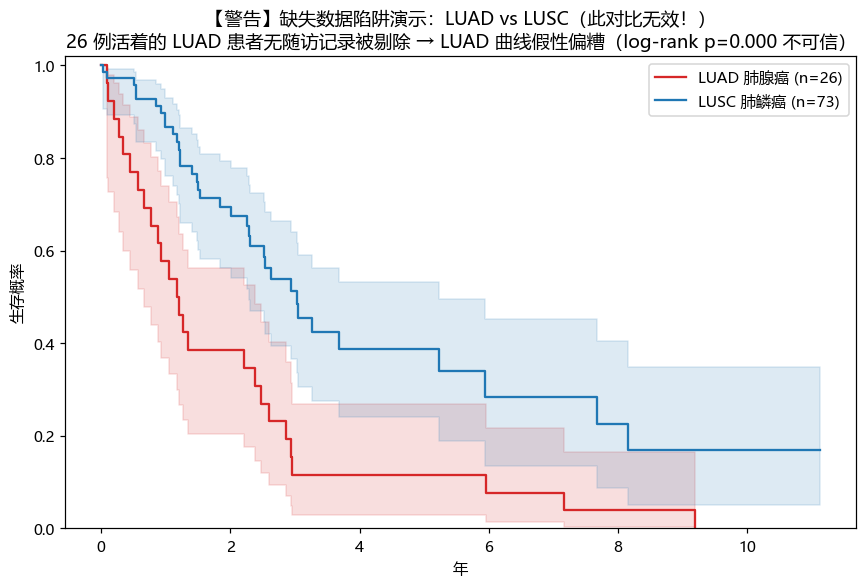

In [ ]:
# 9a. ⚠️ v1 输出回放（生存表有偏，结果作废，仅作反面教材；v1 文件归档在 results/archive_v1/survival/）
import pathlib
from IPython.display import Image, display
out_dir = pathlib.Path(f'{PROJ}/results/archive_v1/survival')
print((out_dir / 'run_log.txt').read_text(encoding='utf-8'))
display(Image(filename=str(out_dir / 'km_by_stage.png')))
display(Image(filename=str(out_dir / 'km_luad_vs_lusc.png')))


### 📊 v1 生存结果（作废，保留作反面教材）

- v1 缺失表：被剔除的 45 例 = 44 例活着的 LUAD + 1 例死亡但没有死亡时间的 LUSC。日志里的"26 例""97 个患者"是 100 张时代写死在代码里的旧数字，没随数据更新——
  "97 个患者中 99 个有完整生存记录"这种自相矛盾的句子，本身就是一个该被测试拦住的信号。
- 留下的 99 例里，LUAD 26 例全部死亡，LUSC 73 例中 35 例死亡。
- 分期 KM（I 51 / II 28 / III 15 / IV 2，I vs III p=0.26）同样受这个偏倚影响，不能解读为"方向符合临床常识"。
- 方法论提醒仍然成立：LUAD/LUSC 是病理分型，不是预后分组；TCGA 是方便样本，两个项目的入组来源也不同，亚型间的生存比较只能描述，不能当预后结论。

### 9b. Cox 预后建模（v1 结果作废；v2 方案）

v1 输出（下方）：单因素分期 HR=1.29、亚型 HR=0.39；OOF C-index 临床 0.561 / 形态 0.500 / 联合 0.517；风险分组 log-rank p=0.92。
这些数字建立在 §9 的有偏生存表和不一致的形态嵌入上，都不能用——包括"形态嵌入对预后没有预测力"这个阴性结论：它既不能证明有，也不能证明没有。

**v2**（`analysis_cox.py`）：
1. 先过缺失检查，不通过就退出；
2. 临床模型：分期组哑变量（II、III-IV，以 I 为参照）+ 年龄 + 性别，**以亚型分层**（每个亚型有自己的基线风险，不再把亚型当预后因子）；
3. 形态：meanpool PC（训练折内拟合标准化和 PCA），或每折 CLAM 模型空间；
4. 重复分层 5 折（默认 20 次）：每折 C-index 的均值 ± SD、池化 OOF C-index，ΔC（加形态 − 不加）在各次重复上的分布，再加患者 bootstrap 95% 区间；
5. 风险高低组的阈值取训练折风险分的中位数（v1 用全体 OOF 风险分的中位数，用到了测试患者的信息）；
6. 比例风险假设检验（Schoenfeld 残差）。

样本量提醒：144 例、预计几十个事件，临床 4 个参数 + 形态 5 个 PC，每参数事件数在 10 上下。C-index 的 95% 区间宽度会在 ±0.05–0.1，期望要放低。
真想做预后，需要更大的队列和专门的生存模型（如 DeepAttnMISL、AttnMIL + Cox 损失）。

== 单因素 Cox ==
分期(序数): HR=1.29, p=0.084 (n=96)
年龄: HR=1.00, p=0.844 (n=99)
亚型(LUSC=1): HR=0.39, p=0.000 (n=99)

== OOF C-index（n=96）==
临床: 0.561
形态: 0.500
临床+形态: 0.517

风险分组 KM log-rank p=0.920

声明: 26 例 Alive LUAD 无随访被剔除，结果为方法学演示。


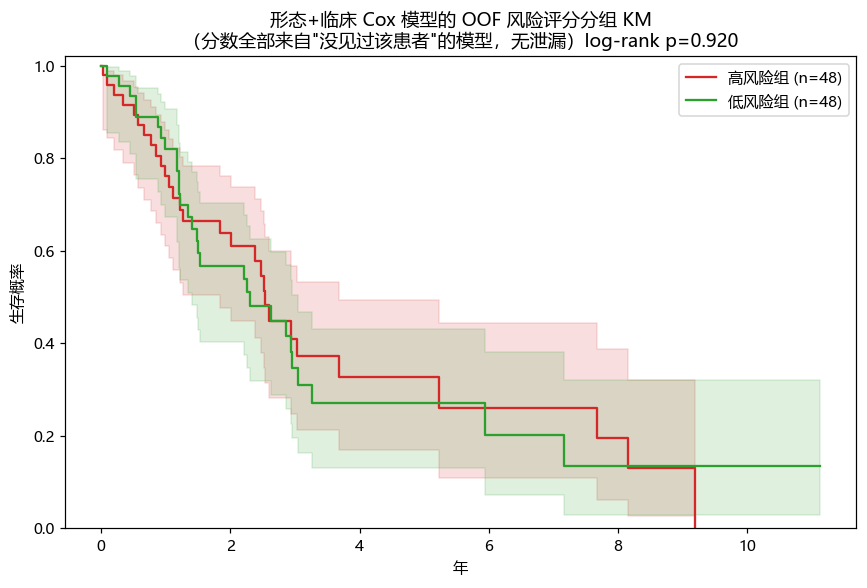

In [ ]:
# 9b. ⚠️ v1 输出回放：Cox 汇总 + 高低风险组 KM（作废；v2 重跑命令见 §8 末尾的代码格）
out9 = pathlib.Path(f'{PROJ}/results/archive_v1/survival')
print((out9 / 'cox_summary.txt').read_text(encoding='utf-8'))
display(Image(filename=str(out9 / 'km_risk_groups.png')))


## 10. 踩坑速查表（全文最有复用价值的一节）

| # | 症状 | 根因 | 解法 |
|---|---|---|---|
| 1 | `conda` 命令不存在 | 自定义路径安装 + 老终端不刷新 PATH | 查开始菜单快捷方式的 Arguments 定位安装目录 |
| 2 | `CondaToSNonInteractiveError` | 新版 conda 要先接受频道条款 | `conda tos accept --override-channels --channel ...` ×3 |
| 3 | pip 装任何包都 `SSLEOFError` | 网络中间设备精准掐 pip 的 TLS 指纹（curl/浏览器却正常） | 换 uv（Rust 的 rustls，指纹不同） |
| 4 | uv 下 torch 中途断流；wheel 才 118MB | PyPI 的 Windows torch 是 CPU 版；大文件长连接被断 | 从 download.pytorch.org 用 curl `-C -` 断点续传，再本地装 |
| 5 | `No module named 'future'` | smooth-topk 没声明这个依赖 | `uv pip install future` |
| 6 | `Couldn't locate OpenSlide DLL` | Python≥3.8 的 ctypes 不再搜索 PATH | `uv pip install openslide-bin` |
| 7 | timm 说 hf hub 没装（装了也说） | huggingface_hub≥0.26 删了 `cached_download` | 钉版 `huggingface_hub==0.25.2` |
| 8 | HF 请求 `ProxyError` | 系统代理注册表开着但代理没跑，requests 被截杀 | 权重离线播种缓存 + `HF_HUB_OFFLINE=1` |
| 9 | `ctypes objects cannot be pickled` | Windows 的 spawn 多进程 pickle 不了 OpenSlide 对象 | `extract_features_fp.py` 的 num_workers 补丁 |
| 10 | curl 报 `CRYPT_E_REVOCATION_OFFLINE` | Windows schannel 查不到证书吊销列表 | Windows 版 curl 加 `--ssl-no-revoke` |
| 11 | 以为"5 折 CV = 每张恰好考一次"；MC 均值在 100→150 时从 0.919 崩到 0.788 | CLAM `create_splits_seq` 实为蒙特卡洛 CV（每折独立随机 80/10/10）；150 张里 98 张（65%）从未进测试集，单折抽签到难病人就崩 | 双协议都跑：官方 MC（可比性）+ `make_strict_splits.py` 的 StratifiedGroupKFold（每患者恰考一次）（§4/§6） |
| 12 | eval.py 评估报错或结果目录名诡异 | 三个机关：`--save_exp_code` 会被自动加 `EVAL_` 前缀；`--splits_dir` 要给含 `splits/` 的路径（不是划分目录名）；它没有 `--subtyping` 参数（那是 main.py 的） | 照 §6 的命令抄 |
| 13 | 后台多折连跑，某折 45 秒静默消失、循环继续跑下一折，最后才发现少了 checkpoint | Windows 提交内存抖动杀进程，`tail -6` 把报错截没了 | 命令行加 `-X faulthandler`；每折输出 `tail -40` 留报错；循环开头用 checkpoint 存在性做跳过守卫，补跑直接重发同一循环 |
| 14 | 多组学结果里混进了癌旁正常组织 | 一个患者有多个 RNA-seq 文件（01 原发 / 11 癌旁正常 / 02 复发），按患者覆盖写入时最后读到的赢 | 下载时保存文件 ↔ 样本类型的元数据，只取原发肿瘤（`common.load_expression`） |
| 15 | 活着的 LUAD 患者全部"没有随访"，LUAD 事件率 100% | 请求 GDC 临床数据时没 expand `follow_ups`；`a or b` 把 0 天当缺失 | `download_tcga.py --metadata-only` 重取临床；或用 TCGA-CDR；缺失按组别 × 结局检查写成程序 |
| 16 | 形态嵌入的主成分在"按折分组" | 每张切片用自己测试折的模型提嵌入，5 个模型的空间不同 | 用不依赖训练的嵌入（meanpool），或每折模型只在自己的折内拟合与评估（`embed_slides.py`） |
| 17 | 模型可能在"认医院" | TCGA 每个组织来源中心只贡献一种亚型，中心和标签完全重合 | `make_strict_splits.py --group-by site` 按中心分组；`eval_cv_summary.py` 看见过/没见过中心的成绩 |
| 18 | 热图标题里的概率比 fold_k.csv 里的更接近 0.5 | `Y_prob` 已经是 softmax 概率，又做了一次 softmax | 直接用 `Y_prob`（`make_heatmap.py` 已修） |
| 19 | 重新生成的严格折和原来的对不上 | 同一 seed 下，不同 sklearn 版本的 `StratifiedGroupKFold` 结果不同 | 划分文件随结果入库，复现时直接用文件 |

每个坑的完整排查过程（含原始报错）见 `../docs/clam-setup-log.md`。

## 11. 跑通之后，还能做什么？

按优先级：
- **先把 v2 跑完**（§8 末尾的代码格）：补样本元数据和随访 → 提嵌入 → 多组学 / 生存 / Cox。跑完后把 §8、§9 的 v1 说明换成 v2 结果。
- **按中心分组重训一遍**（`make_strict_splits.py --group-by site`）：回答"模型是不是在认医院"，这是本数据集评估里最大的未知数。
- **统一倍率**（§3 ⚠️）：`check_slide_mpp.py` 看分布，混了 20×/40× 就统一到 20× 等效后重新切块、提特征。
- **更强的特征提取器**：CONCH（视觉-语言模型，512 维，6GB 显存小 batch 可试）、UNI2-h（1536 维，本机显存紧张）。注意基础模型并没有消除中心/扫描仪差异（见 UNI2 玩具版第 5 节），换了特征也要做按中心分组的评估。
- **更多数据**：`download_tcga.py --n 100` 扩到每类 100 张，已下载的切片自动保留、断点续传不重复下载。
- **预后**：用 TCGA-CDR 的 OS/PFI 终点、更大的队列和专门的生存模型（如 DeepAttnMISL、AttnMIL + Cox 损失）；本项目 144 例的规模只够演示方法。
- **官方新工具**：[Trident](https://github.com/mahmoodlab/TRIDENT)（Mahmood Lab 的新一代切块 + 特征提取工具，一个接口调用多种病理基础模型）。